In [1]:
!pip install nibabel torch torchvision
!pip install lpips
!pip install torchio
# IMPORTS - Medical Image Translation Metrics

# Standard Library
import math
import random
import itertools
import functools
import os, glob
import gc

# Numerical & Scientific Computing
import numpy as np
from scipy.io import loadmat
from scipy.stats import pearsonr, entropy
from scipy.ndimage import convolve

# Image Processing
from PIL import Image
import imageio
import matplotlib.pyplot as plt

# Medical Imaging
import nibabel as nib

# Machine Learning - scikit-learn
from sklearn.metrics import mutual_info_score, normalized_mutual_info_score

# Deep Learning - PyTorch
import torch
import torch as pt  # Alternative import name used in FSIM
import torch.nn as nn
from torch import optim
from torch.autograd import Variable
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as FUN  # Alternative import name used in FSIM
import torch.nn.functional as F
from torchvision import transforms
import torchio as tio

# Perceptual Metrics
import lpips

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.6/203.6 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 3.8 MB/s eta 0:00:00


In [2]:
# Force system RAM cleanup (Garbage Collector)
gc.collect()

# Clear residual GPU memory
torch.cuda.empty_cache()

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

In [4]:
import torch
import torchio as tio
from torch.utils.data import Dataset

# 2. CREAZIONE DEL WRAPPER DI ADATTAMENTO
class TorchIOWrapper(Dataset):
    """
    This wrapper acts as the legacy NiftiPairedDataset.
    Extracts the native tensor from TorchIO and permutes the axes into the 
    correct shape, preventing evaluation function errors.
    """
    def __init__(self, tio_dataset):
        self.tio_dataset = tio_dataset
        
    def __len__(self):
        return len(self.tio_dataset)
        
    def __getitem__(self, idx):
        subject = self.tio_dataset[idx]
        
        # TorchIO returns volumes as [Channels, W, H, D].
        # Permuting axes to [Channels, D, H, W] using indices (0, 3, 2, 1).
        img_A = subject['A'][tio.DATA].permute(0, 3, 2, 1)
        img_B = subject['B'][tio.DATA].permute(0, 3, 2, 1)
        
        # Returns a simple dictionary like NiftiPairedDataset
        return {'A': img_A, 'B': img_B}



In [5]:
def ssim_structure(img1, img2):
    """
    Compute the structural similarity index (SSIM) focusing only on the structure component.
    
    Parameters:
    - img1: First image (grayscale).
    - img2: Second image (grayscale).
    
    Returns:
    - Structural similarity index focusing only on structure.
    """
    # Ensure the input images are in float format
    #img1 = img1.astype(np.float64)
    #img2 = img2.astype(np.float64)
    
    # Define constants for numerical stability
    #C3 = 1e-15
    C3 = (0.03 * (2**8 - 1))**2 / 2

    # Compute the mean of the images
    mu1 = np.mean(img1)
    mu2 = np.mean(img2)
    
    # Compute the standard deviation of the images
    sigma1 = np.std(img1)
    sigma2 = np.std(img2)
    
    # Compute the covariance between the images
    covariance = np.mean((img1 - mu1) * (img2 - mu2))
    
    # Compute the structural similarity index focusing only on the structure component
    ssim_structure_component = (covariance + C3) / (sigma1 * sigma2 + C3)
    
    return ssim_structure_component

def normalize_image(image):
    """ Normalize image to the range [0, 1]. """
    image = image.astype(np.float64)
    return 255*(image - np.min(image)) / (np.max(image) - np.min(image))

def calculate_3d_ssim(image1, image2):
    assert image1.shape == image2.shape, "Input images must have the same dimensions"
    
    # Normalize images to [0, 1] range
    image1 = normalize_image(image1)
    image2 = normalize_image(image2)
    
    # Dimensions of the 3D images
    H, W, D = image1.shape
    
    # Calculate SSIM for each slice along the third axis (depth)
    ssim_values = []
    for i in range(D):
        slice1 = image1[:, :, i]
        slice2 = image2[:, :, i]
        slice_ssim = ssim_structure(slice1, slice2)  # data_range is 1 since images are normalized
        ssim_values.append(slice_ssim)
        
    for i in range(W):
        slice1 = image1[:, i, :]
        slice2 = image2[:, i, :]
        slice_ssim = ssim_structure(slice1, slice2)  # data_range is 1 since images are normalized
        ssim_values.append(slice_ssim)
    
    for i in range(H):
        slice1 = image1[i, :, :]
        slice2 = image2[i, :, :]
        slice_ssim = ssim_structure(slice1, slice2) # data_range is 1 since images are normalized
        ssim_values.append(slice_ssim)
    
    # Average the SSIM values for all slices
    mean_ssim = np.mean(ssim_values)
    std_ssim = np.std(ssim_values)
    
    
    return mean_ssim, ssim_values, std_ssim

def calculate_ssim_for_image_lists(list1, list2):
    # Ensure the two lists have the same length
    assert len(list1) == len(list2), "The two lists must have the same number of images"
    
    # Initialize a list to store the SSIM indices for each pair of images
    ssim_results = []
    
    # Loop through each pair of images from list1 and list2
    for img1, img2 in zip(list1, list2):
        mean_ssim, ssim_values, std_ssim = calculate_3d_ssim(img1, img2)
        
        ssim_results.append(mean_ssim)
    
    return ssim_results

def calculate_ssim_for_single_list(image_list, max_pairs=None, seed=None):
    """
    Compute full 3D SSIM for randomly selected pairs from a single list of 3D images.

    Parameters:
        image_list (list of np.ndarray): List of 3D images (H, W, D).
        max_pairs (int, optional): Maximum number of pairs to evaluate.
                                   If None, use all possible pairs.
        seed (int, optional): Random seed for reproducibility.

    Returns:
        mean_val (float): Mean SSIM across selected pairs.
        std_val (float): Std.dev SSIM across selected pairs.
        values (list of float): Individual SSIM values for each pair.
        pairs (list of tuple): Indices of image pairs that were evaluated.
    """
    n = len(image_list)
    assert n >= 2, "Need at least two images to compute SSIM."

    # All possible unique pairs
    all_pairs = list(itertools.combinations(range(n), 2))

    # Subsample pairs if requested
    if max_pairs is not None and max_pairs < len(all_pairs):
        if seed is not None:
            random.seed(seed)
        pairs = random.sample(all_pairs, max_pairs)
    else:
        pairs = all_pairs

    values = []
    for i, j in pairs:
        mean_ssim, _, _ = calculate_3d_ssim(image_list[i], image_list[j])
        values.append(mean_ssim)

    mean_val = float(np.mean(values)) if values else float("nan")
    std_val = float(np.std(values)) if values else float("nan")

    return mean_val, std_val, values, pairs



def ssim_full(img1, img2):
    """
    Compute the full SSIM (luminance, contrast, structure) between two 2D slices.
    """
    C1 = (0.01 * (2**8 - 1))**2
    C2 = (0.03 * (2**8 - 1))**2

    mu1 = np.mean(img1)
    mu2 = np.mean(img2)

    sigma1_sq = np.var(img1)
    sigma2_sq = np.var(img2)
    sigma12 = np.mean((img1 - mu1) * (img2 - mu2))

    numerator = (2 * mu1 * mu2 + C1) * (2 * sigma12 + C2)
    denominator = (mu1**2 + mu2**2 + C1) * (sigma1_sq + sigma2_sq + C2)

    return numerator / denominator


def normalize_image(image):
    """ Normalize image to [0, 255] range (float). """
    image = image.astype(np.float64)
    return 255 * (image - np.min(image)) / (np.max(image) - np.min(image) + 1e-12)


def calculate_3d_full_ssim(image1, image2):
    """
    Compute mean and std of full SSIM across all 2D slices along H, W, and D.
    """
    assert image1.shape == image2.shape, "Input images must have the same dimensions"
    
    image1 = normalize_image(image1)
    image2 = normalize_image(image2)
    
    H, W, D = image1.shape
    ssim_values = []

    # Slice along depth
    for i in range(D):
        ssim_values.append(ssim_full(image1[:, :, i], image2[:, :, i]))
    # Slice along width
    for i in range(W):
        ssim_values.append(ssim_full(image1[:, i, :], image2[:, i, :]))
    # Slice along height
    for i in range(H):
        ssim_values.append(ssim_full(image1[i, :, :], image2[i, :, :]))
    
    mean_ssim = np.mean(ssim_values)
    std_ssim = np.std(ssim_values)
    
    return mean_ssim, ssim_values, std_ssim


def calculate_full_ssim_for_image_lists(list1, list2):
    """
    Compute full 3D SSIM for two lists of 3D images (same length).
    Returns a list of mean SSIM values (one per pair).
    """
    assert len(list1) == len(list2), "Both lists must have the same number of images"
    
    ssim_results = []
    for img1, img2 in zip(list1, list2):
        mean_ssim, _, _ = calculate_3d_full_ssim(img1, img2)
        ssim_results.append(mean_ssim)
    
    return ssim_results


def calculate_full_ssim_for_single_list(image_list, max_pairs=None, seed=None):
    """
    Compute full 3D SSIM for randomly selected pairs from a single list of 3D images.

    Parameters:
        image_list (list of np.ndarray): List of 3D images (H, W, D).
        max_pairs (int, optional): Maximum number of pairs to evaluate.
                                   If None, use all possible pairs.
        seed (int, optional): Random seed for reproducibility.

    Returns:
        mean_val (float): Mean SSIM across selected pairs.
        std_val (float): Std.dev SSIM across selected pairs.
        values (list of float): Individual SSIM values for each pair.
        pairs (list of tuple): Indices of image pairs that were evaluated.
    """
    n = len(image_list)
    assert n >= 2, "Need at least two images to compute SSIM."

    # All possible unique pairs
    all_pairs = list(itertools.combinations(range(n), 2))

    # Subsample pairs if requested
    if max_pairs is not None and max_pairs < len(all_pairs):
        if seed is not None:
            random.seed(seed)
        pairs = random.sample(all_pairs, max_pairs)
    else:
        pairs = all_pairs

    values = []
    for i, j in pairs:
        mean_ssim, _, _ = calculate_3d_full_ssim(image_list[i], image_list[j])
        values.append(mean_ssim)

    mean_val = float(np.mean(values)) if values else float("nan")
    std_val = float(np.std(values)) if values else float("nan")

    return mean_val, std_val, values, pairs



def ssim_luminance(img1, img2):
    """
    Compute the luminance component of SSIM between two 2D slices.
    """
    C1 = (0.01 * (2**8 - 1))**2

    mu1 = np.mean(img1)
    mu2 = np.mean(img2)

    l = (2 * mu1 * mu2 + C1) / (mu1**2 + mu2**2 + C1)
    return l


def calculate_3d_luminance_ssim(image1, image2):
    """
    Compute mean and std of luminance SSIM across all 2D slices along H, W, and D.
    """
    assert image1.shape == image2.shape, "Input images must have the same dimensions"

    # Normalize images to [0,255]
    def normalize_image(img):
        img = img.astype(np.float64)
        return 255 * (img - np.min(img)) / (np.max(img) - np.min(img) + 1e-12)

    image1 = normalize_image(image1)
    image2 = normalize_image(image2)

    H, W, D = image1.shape
    ssim_values = []

    # Slice along depth
    for i in range(D):
        ssim_values.append(ssim_luminance(image1[:, :, i], image2[:, :, i]))
    # Slice along width
    for i in range(W):
        ssim_values.append(ssim_luminance(image1[:, i, :], image2[:, i, :]))
    # Slice along height
    for i in range(H):
        ssim_values.append(ssim_luminance(image1[i, :, :], image2[i, :, :]))

    mean_ssim = np.mean(ssim_values)
    std_ssim = np.std(ssim_values)

    return mean_ssim, ssim_values, std_ssim


def calculate_luminance_ssim_for_single_list(image_list, max_pairs=None, seed=None):
    """
    Compute luminance-only 3D SSIM for randomly selected pairs from a single list of 3D images.

    Parameters:
        image_list (list of np.ndarray): List of 3D images (H, W, D).
        max_pairs (int, optional): Maximum number of pairs to evaluate.
                                   If None, use all possible pairs.
        seed (int, optional): Random seed for reproducibility.

    Returns:
        mean_val (float): Mean luminance SSIM across selected pairs.
        std_val (float): Std.dev luminance SSIM across selected pairs.
        values (list of float): Individual luminance SSIM values for each pair.
        pairs (list of tuple): Indices of image pairs that were evaluated.
    """
    n = len(image_list)
    assert n >= 2, "Need at least two images to compute SSIM."

    all_pairs = list(itertools.combinations(range(n), 2))

    # Subsample if requested
    if max_pairs is not None and max_pairs < len(all_pairs):
        if seed is not None:
            random.seed(seed)
        pairs = random.sample(all_pairs, max_pairs)
    else:
        pairs = all_pairs

    values = []
    for i, j in pairs:
        mean_ssim, _, _ = calculate_3d_luminance_ssim(image_list[i], image_list[j])
        values.append(mean_ssim)

    mean_val = float(np.mean(values)) if values else float("nan")
    std_val = float(np.std(values)) if values else float("nan")

    return mean_val, std_val, values, pairs

In [6]:
def calculate_3d_ncc_volume(pred, target):
    """
    Calculate NCC on the entire 3D volume.
    
    NCC is particularly good for cross-modal MRI comparison because it's
    invariant to linear intensity transformations (brightness/contrast changes).
    
    Returns:
        mean_ncc: NCC value in range [-1, 1]
        ncc_values: [ncc] (single value in list for consistency)
        std_ncc: 0.0 (no variation for single volume)
    """
    pred = normalize_to_0_1(pred.astype(np.float64))
    target = normalize_to_0_1(target.astype(np.float64))
    
    # Subtract means
    pred_mean = pred - np.mean(pred)
    target_mean = target - np.mean(target)
    
    # Calculate NCC
    numerator = np.sum(pred_mean * target_mean)
    denominator = np.sqrt(np.sum(pred_mean**2) * np.sum(target_mean**2))
    
    ncc = numerator / (denominator + 1e-8)
    
    # Return in same format as slice-wise functions
    return ncc, [ncc], 0.0


def calculate_3d_ncc_slicewise(pred, target):
    """
    Calculate NCC slice-wise along all three dimensions (axial, sagittal, coronal).
    
    This gives you statistics about how well the correlation holds across
    different slice orientations.
    
    Returns:
        mean_ncc: Mean NCC across all slices
        ncc_values: List of all NCC values
        std_ncc: Standard deviation of NCC values
    """
    pred = normalize_to_0_1(pred.astype(np.float64))
    target = normalize_to_0_1(target.astype(np.float64))
    
    ncc_values = []
    
    # Calculate NCC for each slice in all three dimensions
    for axis in range(3):
        for i in range(pred.shape[axis]):
            pred_slice = np.take(pred, i, axis=axis)
            target_slice = np.take(target, i, axis=axis)
            
            # Subtract means
            pred_mean = pred_slice - np.mean(pred_slice)
            target_mean = target_slice - np.mean(target_slice)
            
            # Calculate NCC for this slice
            numerator = np.sum(pred_mean * target_mean)
            denominator = np.sqrt(np.sum(pred_mean**2) * np.sum(target_mean**2))
            
            ncc = numerator / (denominator + 1e-8)
            ncc_values.append(ncc)
    
    return np.mean(ncc_values), ncc_values, np.std(ncc_values)


def calculate_3d_ncc_axial_only(pred, target):
    """
    Calculate NCC only on axial slices (axis=2).
    Useful if you want to focus on the primary acquisition plane.
    
    Returns:
        mean_ncc: Mean NCC across axial slices
        ncc_values: List of NCC values per slice
        std_ncc: Standard deviation
    """
    pred = normalize_to_0_1(pred.astype(np.float64))
    target = normalize_to_0_1(target.astype(np.float64))
    
    ncc_values = []
    
    # Only axial slices (typically the acquisition plane)
    for i in range(pred.shape[2]):
        pred_slice = pred[:, :, i]
        target_slice = target[:, :, i]
        
        pred_mean = pred_slice - np.mean(pred_slice)
        target_mean = target_slice - np.mean(target_slice)
        
        numerator = np.sum(pred_mean * target_mean)
        denominator = np.sqrt(np.sum(pred_mean**2) * np.sum(target_mean**2))
        
        ncc = numerator / (denominator + 1e-8)
        ncc_values.append(ncc)
    
    return np.mean(ncc_values), ncc_values, np.std(ncc_values)

In [7]:
def normalize_to_0_1(img):
    """Normalizza immagine a [0, 1]"""
    img_min = img.min()
    img_max = img.max()
    return (img - img_min) / (img_max - img_min + 1e-8)

def denormalize_tanh_to_01(img):
    """
    Se il modello usa tanh (output [-1, 1]), converti a [0, 1]
    """
    return (img + 1.0) / 2.0

# PSNR UTILITIES
def psnr_from_mse(mse, data_range):
    return float('inf') if mse == 0 else 20 * np.log10(data_range / np.sqrt(mse))

def calculate_3d_psnr_volume(image1, image2, data_range=None):
    """
    PSNR calcolato sull'intero volume 3D.
    IMPORTANTE: entrambe le immagini devono essere nello stesso range!
    """
    image1 = normalize_to_0_1(image1.astype(np.float64))
    image2 = normalize_to_0_1(image2.astype(np.float64))
    
    if data_range is None:
        data_range = 1.0
    
    mse = np.mean((image1 - image2) ** 2)
    return psnr_from_mse(mse, data_range)

def calculate_3d_psnr_slicewise(image1, image2, data_range=None):
    """
    PSNR calcolato slice-wise lungo tutte le dimensioni.
    """
    image1 = normalize_to_0_1(image1.astype(np.float64))
    image2 = normalize_to_0_1(image2.astype(np.float64))
    
    if data_range is None:
        data_range = 1.0
    
    psnr_values = []
    for axis in range(3):
        for i in range(image1.shape[axis]):
            slice1 = np.take(image1, i, axis=axis)
            slice2 = np.take(image2, i, axis=axis)
            mse = np.mean((slice1 - slice2) ** 2)
            psnr_values.append(psnr_from_mse(mse, data_range))
    
    return np.mean(psnr_values), psnr_values, np.std(psnr_values)

In [8]:
'''
This code is a direct pytorch implementation of the original FSIM code provided by
Lin ZHANG, Lei Zhang, Xuanqin Mou and David Zhang in Matlab. For the original version
please see: 

https://www4.comp.polyu.edu.hk/~cslzhang/IQA/FSIM/FSIM.htm

'''


class FSIM_base(nn.Module):

    def __init__(self):
        nn.Module.__init__(self)
        self.cuda_computation = False
        self.nscale = 4 # Number of wavelet scales
        self.norient = 4 # Number of filter orientations
        self.k = 2.0 # No of standard deviations of the noise
                     # energy beyond the mean at which we set the
                     # noise threshold point. 
                     # below which phase congruency values get
                     # penalized.

        self.epsilon = .0001 # Used to prevent division by zero
        self.pi = math.pi
        
        minWaveLength = 6  # Wavelength of smallest scale filter
        mult = 2  # Scaling factor between successive filters
        sigmaOnf = 0.55 # Ratio of the standard deviation of the
                        # Gaussian describing the log Gabor filter's
                        # transfer function in the frequency domain
                        # to the filter center frequency.    
        dThetaOnSigma = 1.2 # Ratio of angular interval between filter orientations    
                            # and the standard deviation of the angular Gaussian
                            # function used to construct filters in the
                            # freq. plane.
        
        self.thetaSigma = self.pi/self.norient/dThetaOnSigma # Calculate the standard deviation of the
                                                             # angular Gaussian function used to
                                                             # construct filters in the freq. plane.
        

        self.fo = (1.0/(minWaveLength*pt.pow(mult,(pt.arange(0,self.nscale,dtype=pt.float64))))).unsqueeze(0) # Centre frequency of filter
        self.den = 2*(math.log(sigmaOnf))**2
        self.dx = -pt.tensor([[[[3, 0, -3], [10, 0,-10], [3,0,-3]]]])/16.0
        self.dy = -pt.tensor([[[[3, 10, 3], [0, 0, 0],   [-3 ,-10, -3]]]])/16.0
        self.T1 = 0.85
        self.T2 = 160
        self.T3 = 200;
        self.T4 = 200;
        self.lambdac = 0.03

    def set_arrays_to_cuda(self):
        self.cuda_computation = True
        self.fo = self.fo.cuda()
        self.dx = self.dx.cuda()
        self.dy = self.dy.cuda()
    
    def forward_gradloss(self,imgr,imgd):
        I1,Q1,Y1 = self.process_image_channels(imgr)
        I2,Q2,Y2 = self.process_image_channels(imgd)

        
        #PCSimMatrix,PCm = self.calculate_phase_score(PC1,PC2)
        gradientMap1 = self.calculate_gradient_map(Y1)
        gradientMap2 = self.calculate_gradient_map(Y2)
        
        gradientSimMatrix = self.calculate_gradient_sim(gradientMap1,gradientMap2)
        #gradientSimMatrix= gradientSimMatrix.view(PCSimMatrix.size())
        gradloss = pt.sum(pt.sum(pt.sum(gradientSimMatrix,1),1))
        return gradloss
    
    def calculate_fsim(self,gradientSimMatrix,PCSimMatrix,PCm):
        SimMatrix = gradientSimMatrix * PCSimMatrix * PCm
        FSIM = pt.sum(pt.sum(SimMatrix,1),1) / pt.sum(pt.sum(PCm,1),1)
        return FSIM

    def calculate_fsimc(self, I1,Q1,I2,Q2,gradientSimMatrix,PCSimMatrix,PCm):

        ISimMatrix = (2*I1*I2 + self.T3) / (pt.pow(I1,2) + pt.pow(I2,2) + self.T3)
        QSimMatrix = (2*Q1*Q2 + self.T4) / (pt.pow(Q1,2) + pt.pow(Q2,2) + self.T4)
        SimMatrixC = gradientSimMatrix*PCSimMatrix*(pt.pow(pt.abs(ISimMatrix*QSimMatrix),self.lambdac))*PCm
        FSIMc = pt.sum(pt.sum(SimMatrixC,1),1)/pt.sum(pt.sum(PCm,1),1)

        return FSIMc
    
    def lowpassfilter(self, rows, cols):
        cutoff = .45
        n = 15
        x, y = self.create_meshgrid(cols,rows)
        radius = pt.sqrt(pt.pow(x,2) + pt.pow(y,2)).unsqueeze(0)       
        f = self.ifftshift2d( 1 / (1.0 + pt.pow(pt.div(radius,cutoff),2*n)) ) 
        return f
    
    def calculate_gradient_sim(self,gradientMap1,gradientMap2):

        gradientSimMatrix = (2*gradientMap1*gradientMap2 + self.T2) /(pt.pow(gradientMap1,2) + pt.pow(gradientMap2,2) + self.T2)
        return gradientSimMatrix

    def calculate_gradient_map(self,Y):
        IxY = FUN.conv2d(Y,self.dx, padding=1)
        IyY = FUN.conv2d(Y,self.dy, padding=1)
        gradientMap1 = pt.sqrt(pt.pow(IxY,2) + pt.pow(IyY,2))
        return gradientMap1
    
    def calculate_phase_score(self,PC1,PC2):
        PCSimMatrix = (2 * PC1 * PC2 + self.T1) / (pt.pow(PC1,2) + pt.pow(PC2,2) + self.T1)
        PCm = pt.where(PC1>PC2, PC1,PC2)
        return PCSimMatrix,PCm    
    
    def roll_1(self,x, n):  
        return pt.cat((x[:,-n:,:,:,:], x[:,:-n,:,:,:]), dim=1)        
        
    def ifftshift(self,tens,var_axis):
        len11 = int(tens.size()[var_axis]/2)
        len12 = tens.size()[var_axis]-len11
        return pt.cat((tens.narrow(var_axis,len11,len12),tens.narrow(var_axis,0,len11)),axis=var_axis)

    def ifftshift2d(self,tens):
        return self.ifftshift(self.ifftshift(tens,1),2)

    #def create_meshgrid(self,cols,rows):
    #    '''
    #    Set up X and Y matrices with ranges normalised to +/- 0.5
    #    The following code adjusts things appropriately for odd and even values
    #    of rows and columns.
    #    '''
#
    #    if cols%2:
    #        xrange = pt.arange(start = -(cols-1)/2, end = (cols-1)/2+1, step = 1, requires_grad=False)/(cols-1)
    #    else:
    #        xrange = pt.arange(-(cols)/2, (cols)/2, step = 1, requires_grad=False)/(cols)
#
    #    if rows%2:
    #        yrange = pt.arange(-(rows-1)/2, (rows-1)/2+1, step = 1, requires_grad=False)/(rows-1)
    #    else:
    #        yrange = pt.arange(-(rows)/2, (rows)/2, step = 1, requires_grad=False)/(rows)
#
    #    x, y = pt.meshgrid([xrange, yrange])
    #    
    #    if self.cuda_computation:
    #        x, y = x.cuda(), y.cuda()
    #        
    #    return x.T, y.T
    
    def create_meshgrid(self, cols, rows):
        '''
        Set up X and Y matrices with ranges normalised to +/- 0.5
        The following code adjusts things appropriately for odd and even values
        of rows and columns.
        '''
    
        if cols%2:
            xrange = pt.arange(start = -(cols-1)/2, end = (cols-1)/2+1, step = 1, requires_grad=False)/(cols-1)
        else:
            xrange = pt.arange(-(cols)/2, (cols)/2, step = 1, requires_grad=False)/(cols)
    
        if rows%2:
            yrange = pt.arange(-(rows-1)/2, (rows-1)/2+1, step = 1, requires_grad=False)/(rows-1)
        else:
            yrange = pt.arange(-(rows)/2, (rows)/2, step = 1, requires_grad=False)/(rows)
    
        # OLD: x, y = pt.meshgrid([xrange, yrange])
        # NEW: Add indexing='ij' to maintain original behavior
        x, y = pt.meshgrid(xrange, yrange, indexing='ij')
        
        if self.cuda_computation:
            x, y = x.cuda(), y.cuda()
            
        return x.T, y.T

    def process_image_channels(self,img):


        batch, rows, cols = img.shape[0],img.shape[2],img.shape[3]

        minDimension = min(rows,cols)    

        Ycoef = pt.tensor([[0.299,0.587,0.114]])
        Icoef = pt.tensor([[0.596,-0.274,-0.322]])
        Qcoef = pt.tensor([[0.211,-0.523,0.312]])
        
        if self.cuda_computation:
            Ycoef, Icoef, Qcoef = Ycoef.cuda(), Icoef.cuda(), Qcoef.cuda()

        Yfilt=pt.cat(batch*[pt.cat(rows*cols*[Ycoef.unsqueeze(2)],dim=2).view(1,3,rows,cols)],0)
        Ifilt=pt.cat(batch*[pt.cat(rows*cols*[Icoef.unsqueeze(2)],dim=2).view(1,3,rows,cols)],0)
        Qfilt=pt.cat(batch*[pt.cat(rows*cols*[Qcoef.unsqueeze(2)],dim=2).view(1,3,rows,cols)],0)
        
        # If images have three chanels
        if img.size()[1]==3:
            Y = pt.sum(Yfilt*img,1).unsqueeze(1)
            I = pt.sum(Ifilt*img,1).unsqueeze(1)
            Q = pt.sum(Qfilt*img,1).unsqueeze(1)
        else:
            Y = pt.mean(img,1).unsqueeze(1)
            I = pt.ones(Y.size(),dtype=pt.float64)
            Q = pt.ones(Y.size(),dtype=pt.float64)

        F = max(1,round(minDimension / 256))

        aveKernel = nn.AvgPool2d(kernel_size = F, stride = F, padding =0)# max(0, math.floor(F/2)))
        if self.cuda_computation:
            aveKernel = aveKernel.cuda()
            
        # Make sure that the dimension of the returned image is the same as the input
        I = aveKernel(I)
        Q = aveKernel(Q)
        Y = aveKernel(Y)
        return I,Q,Y

        
    def phasecong2(self, img):
        batch, rows, cols = img.shape[0], img.shape[2], img.shape[3]
    
        # OLD: imagefft = pt.rfft(img, signal_ndim=2, onesided=False)
        # NEW: Use torch.fft.fft2 for 2D FFT
        imagefft = pt.fft.fft2(img.squeeze(1))  # Remove channel dim, apply FFT
        # Stack real and imaginary parts to match old format
        imagefft = pt.stack([imagefft.real, imagefft.imag], dim=-1).unsqueeze(1)
    
        x, y = self.create_meshgrid(cols, rows)
    
        radius = pt.cat(batch*[pt.sqrt(pt.pow(x,2) + pt.pow(y,2)).unsqueeze(0)],0)
        theta = pt.cat(batch*[pt.atan2(-y,x).unsqueeze(0)],0)
    
        radius = self.ifftshift2d(radius)
        theta = self.ifftshift2d(theta)
    
        radius[:,0,0] = 1 
        
        sintheta = pt.sin(theta)
        costheta = pt.cos(theta)
    
        lp = self.lowpassfilter(rows,cols)
        lp = pt.cat(batch*[lp.unsqueeze(0)],0)
     
        term1 = pt.cat(rows*cols*[self.fo.unsqueeze(2)],dim=2).view(-1,self.nscale,rows,cols)
        term1 = pt.cat(batch*[term1.unsqueeze(0)],0).view(-1,self.nscale,rows,cols)
    
        term2 = pt.log(pt.cat(self.nscale*[radius.unsqueeze(1)],1)/term1)
        logGabor = pt.exp(-pt.pow(term2,2)/self.den)
        logGabor = logGabor*lp
        logGabor[:,:,0,0] = 0
    
        angl = pt.arange(0,self.norient,dtype=pt.float64)/self.norient*self.pi
    
        if self.cuda_computation:
            angl = angl.cuda()
        ds_t1 = pt.cat(self.norient*[sintheta.unsqueeze(1)],1)*pt.cos(angl).view(-1,self.norient,1,1)
        ds_t2 = pt.cat(self.norient*[costheta.unsqueeze(1)],1)*pt.sin(angl).view(-1,self.norient,1,1)
        dc_t1 = pt.cat(self.norient*[costheta.unsqueeze(1)],1)*pt.cos(angl).view(-1,self.norient,1,1)
        dc_t2 = pt.cat(self.norient*[sintheta.unsqueeze(1)],1)*pt.sin(angl).view(-1,self.norient,1,1)
        ds = ds_t1-ds_t2
        dc = dc_t1+dc_t2
        dtheta = pt.abs(pt.atan2(ds,dc))
        spread = pt.exp(-pt.pow(dtheta,2)/(2*self.thetaSigma**2))
    
        logGabor_rep = pt.repeat_interleave(logGabor,self.norient,1).view(-1,self.nscale,self.norient,rows,cols)
    
        spread_rep = pt.cat(self.nscale*[spread]).view(-1,self.nscale,self.norient,rows,cols)
        filter_log_spread = logGabor_rep*spread_rep
        
        # Convert filter to complex for FFT operations
        filter_complex = pt.complex(filter_log_spread, pt.zeros_like(filter_log_spread))
        
        # OLD: Used pt.ifft with manual zero padding
        # NEW: Use torch.fft.ifft2
        ifftFilterArray = pt.fft.ifft2(filter_complex).real * math.sqrt(rows*cols)
    
        # Convert imagefft back to complex format for convolution
        imagefft_complex = pt.complex(imagefft[..., 0], imagefft[..., 1])
        imagefft_repeat = pt.cat(self.nscale*self.norient*[imagefft_complex],dim=1).view(-1,self.nscale,self.norient,rows,cols)
        
        # Convolve in frequency domain
        EO = pt.fft.ifft2(filter_complex * imagefft_repeat)
    
        E = EO.real
        O = EO.imag
        
        An = pt.sqrt(pt.pow(E,2)+pt.pow(O,2))
        sumAn_ThisOrient = pt.sum(An,1)
        sumE_ThisOrient = pt.sum(E,1)
        sumO_ThisOrient = pt.sum(O,1)
    
        XEnergy = pt.sqrt(pt.pow(sumE_ThisOrient,2) + pt.pow(sumO_ThisOrient,2)) + self.epsilon
        MeanE = sumE_ThisOrient / XEnergy
        MeanO = sumO_ThisOrient / XEnergy
        
        MeanO = pt.cat(self.nscale*[MeanO.unsqueeze(1)],1)
        MeanE = pt.cat(self.nscale*[MeanE.unsqueeze(1)],1)
    
        Energy = pt.sum( E*MeanE+O*MeanO - pt.abs(E*MeanO-O*MeanE),1)
        abs_EO  = pt.sqrt(pt.pow(E,2) + pt.pow(O,2))
    
        medianE2n = pt.pow(abs_EO.select(1,0),2).view(-1,self.norient,rows*cols).median(2).values
    
        EM_n = pt.sum(pt.sum(pt.pow(filter_log_spread.select(1,0),2),3),2)
        noisePower = -(medianE2n/math.log(0.5))/EM_n
        
        EstSumAn2 = pt.sum(pt.pow(ifftFilterArray,2),1)
    
        sumEstSumAn2 = pt.sum(pt.sum(EstSumAn2,2),2)
        roll_t1 = ifftFilterArray*self.roll_1(ifftFilterArray,1)
        roll_t2 = ifftFilterArray*self.roll_1(ifftFilterArray,2)
        roll_t3 = ifftFilterArray*self.roll_1(ifftFilterArray,3)
        rolling_mult = roll_t1+roll_t2+roll_t3
        EstSumAiAj = pt.sum(rolling_mult,1)/2
        sumEstSumAiAj = pt.sum(pt.sum(EstSumAiAj,2),2)
    
        EstNoiseEnergy2 = 2*noisePower*sumEstSumAn2+4*noisePower*sumEstSumAiAj
        tau = pt.sqrt(EstNoiseEnergy2/2)
        EstNoiseEnergy = tau*math.sqrt(self.pi/2)
        EstNoiseEnergySigma = pt.sqrt( (2-self.pi/2)*pt.pow(tau,2))
    
        T = (EstNoiseEnergy + self.k*EstNoiseEnergySigma)/1.7
        
        T_exp = pt.cat(rows*cols*[T.unsqueeze(2)],dim=2).view(-1,self.norient,rows,cols)
        AnAll = pt.sum(sumAn_ThisOrient,1)
        array_of_zeros_energy = pt.zeros(Energy.size(),dtype=pt.float64)
        if self.cuda_computation:
            array_of_zeros_energy = array_of_zeros_energy.cuda()
            
        EnergyAll = pt.sum(pt.where((Energy - T_exp)<0.0, array_of_zeros_energy,Energy - T_exp ),1)
        ResultPC = EnergyAll/AnAll
        
        return ResultPC
    
class FSIM(FSIM_base):
    '''
    Note, the input is expected to be from 0 to 255
    '''

    def __init__(self):
        super().__init__()
        
    def forward(self,imgr,imgd):
        if imgr.is_cuda:
            self.set_arrays_to_cuda()
            
        I1,Q1,Y1 = self.process_image_channels(imgr)
        I2,Q2,Y2 = self.process_image_channels(imgd)
        PC1 = self.phasecong2(Y1)
        PC2 = self.phasecong2(Y2)
        
        PCSimMatrix,PCm = self.calculate_phase_score(PC1,PC2)
        gradientMap1 = self.calculate_gradient_map(Y1)
        gradientMap2 = self.calculate_gradient_map(Y2)
        
        gradientSimMatrix = self.calculate_gradient_sim(gradientMap1,gradientMap2)
        gradientSimMatrix= gradientSimMatrix.view(PCSimMatrix.size())
        FSIM = self.calculate_fsim(gradientSimMatrix,PCSimMatrix,PCm)

        return FSIM.mean()

class FSIMc(FSIM_base, nn.Module):
    '''
    Note, the input is expected to be from 0 to 255
    '''
    def __init__(self):
        super().__init__()
        
    def forward(self,imgr,imgd):
        if imgr.is_cuda:
            self.set_arrays_to_cuda()
            
            
        I1,Q1,Y1 = self.process_image_channels(imgr)
        I2,Q2,Y2 = self.process_image_channels(imgd)
        PC1 = self.phasecong2(Y1)
        PC2 = self.phasecong2(Y2)
        
        PCSimMatrix,PCm = self.calculate_phase_score(PC1,PC2)
        gradientMap1 = self.calculate_gradient_map(Y1)
        gradientMap2 = self.calculate_gradient_map(Y2)
        
        gradientSimMatrix = self.calculate_gradient_sim(gradientMap1,gradientMap2)
        gradientSimMatrix= gradientSimMatrix.view(PCSimMatrix.size())
        FSIMc = self.calculate_fsimc(I1.squeeze(),Q1.squeeze(),I2.squeeze(),Q2.squeeze(),gradientSimMatrix,PCSimMatrix,PCm)

        return FSIMc.mean()

In [9]:
import matplotlib.pyplot as plt
import numpy as np

def plot_confronto_tre_modelli(ris_modello1, ris_modello2, ris_modello3, 
                               nomi_modelli=['Modello 1', 'Modello 2', 'Modello 3'], 
                               save_path='/kaggle/working/confronto_modelli.png'):
    """
    Genera una griglia di Bar Chart per confrontare 6 metriche cliniche tra 3 modelli diversi.
    Ogni tupla di input deve contenere 12 valori (6 medie + 6 deviazioni standard).
    """
    # 1. Raggruppiamo i risultati per iterarli facilmente
    tutti_i_risultati = [ris_modello1, ris_modello2, ris_modello3]
    
    # Estraiamo medie e std per ogni modello
    medie_modelli = [ris[:6] for ris in tutti_i_risultati]
    stds_modelli = [ris[6:] for ris in tutti_i_risultati]
    
    # 2. Metadati per i grafici (Divisi in "Nome Metrica" e "Spiegazione")
    titoli = [
        ('MAE', '↓ Più basso è meglio (Errore Medio Assoluto)'),
        ('PSNR [dB]', '↑ Più alto è meglio (Rapporto Segnale/Rumore)'),
        ('SSIM', '↑ Più vicino a 1 è meglio (Similarità Strutturale)'),
        ('NCC', '↑ Più vicino a 1 è meglio (Cross-Correlazione)'),
        ('LPIPS', '↓ Più vicino a 0 è meglio (Distanza Percettiva)'),
        ('FSIM', '↑ Più vicino a 1 è meglio (Nitidezza e Fase)')
    ]
    
    # Scegliamo 3 colori distinti per i tre modelli (es. Blu, Arancione, Verde)
    colori_modelli = ['#1f77b4', '#ff7f0e', '#2ca02c']
    
    # 3. Creiamo la griglia 2x3
    fig, axes = plt.subplots(2, 3, figsize=(24, 16))
    fig.suptitle('Confronto Metriche Finali tra 3 Modelli', fontsize=28, fontweight='bold', y=0.98)
    
    for i in range(6):
        row, col = divmod(i, 3)
        ax = axes[row, col]
        
        # Estraiamo i valori per la singola metrica 'i' dai 3 modelli
        medie_metrica = [medie_modelli[m][i] for m in range(3)]
        stds_metrica = [stds_modelli[m][i] for m in range(3)]
        
        # Disegniamo le 3 barre nel subplot
        bars = ax.bar(nomi_modelli, medie_metrica, yerr=stds_metrica, 
                      color=colori_modelli, alpha=0.85, edgecolor='black', linewidth=1.5, 
                      capsize=10, ecolor='black', error_kw={'elinewidth': 2})
        
        # Specificatore di formato
        formato = ".2f" if i == 1 else ".4f" 
        
        # Aggiungiamo i testi sopra ogni singola barra
        for j, bar in enumerate(bars):
            valore = medie_metrica[j]
            errore = stds_metrica[j]
            testo_valore = f"{valore:{formato}}\n(±{errore:{formato}})"
            
            # Calcoliamo la posizione Y del testo per non sovrapporsi all'error bar
            altezza_testo = valore + errore + (max(medie_metrica) * 0.05)
            
            ax.text(bar.get_x() + bar.get_width() / 2, altezza_testo, testo_valore, 
                    ha='center', va='bottom', fontsize=13, fontweight='bold', color='#333333')
        
        # ESTETICA MIGLIORATA PER IL TITOLO E L'ASSE Y
        nome_metrica, sottotitolo = titoli[i]
        
        # Riquadro (Badge) spinto leggermente più in alto (pad=40 invece di 30)
        ax.set_title(nome_metrica, fontsize=22, fontweight='bold', pad=40,
                     bbox=dict(facecolor='#f0f4f8', edgecolor='#cbd5e1', boxstyle='round,pad=0.4', linewidth=1.5))
        
        # Sottotitolo abbassato leggermente (y=1.01 invece di 1.02)
        ax.text(0.5, 1.01, sottotitolo, transform=ax.transAxes, ha='center', va='bottom', 
                fontsize=13, fontstyle='italic', color='#555555')
        
        # Label sull'asse Y per chiarezza aggiuntiva
        ax.set_ylabel(nome_metrica, fontsize=14, fontweight='bold', color='#444444')
        
        # Griglia e assi
        ax.grid(axis='y', linestyle='-', alpha=0.2, color='black')
        ax.set_axisbelow(True)
        
        # Aggiustiamo dinamicamente il limite Y prendendo il massimo tra (media + std) dei 3 modelli
        max_y = max([m + s for m, s in zip(medie_metrica, stds_metrica)])
        ax.set_ylim(0, max_y * 1.35) 
        
        # Rimozione bordi per pulizia
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.tick_params(axis='x', labelsize=15, pad=10)

    # Regoliamo gli spazi tra i subplot (hspace aumentato a 0.40 per compensare il pad=40)
    plt.tight_layout(rect=[0, 0.03, 1, 0.94])
    fig.subplots_adjust(hspace=0.40)
    
    # Salvataggio
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"✅ Bar chart comparativo salvato con successo in: {save_path}")
        
    plt.show()

In [10]:
from torch.utils.data import Dataset, DataLoader
import concurrent.futures
import time
import os
import csv
import numpy as np
import torch
import lpips
import torchio as tio
from tqdm import tqdm
import warnings
from pathlib import Path

class PairedFolderDataset(Dataset):
    def __init__(self, cartella_predizioni, cartella_originali, filtro_modello):
        file_pred = list(Path(cartella_predizioni).rglob('*.nii')) + list(Path(cartella_predizioni).rglob('*.nii.gz'))
        if filtro_modello:
            if isinstance(filtro_modello, list):
                file_pred = [f for f in file_pred if any(fil in str(f) for fil in filtro_modello)]
            else:
                file_pred = [f for f in file_pred if filtro_modello in str(f)]
            
        file_orig = list(Path(cartella_originali).rglob('*.nii')) + list(Path(cartella_originali).rglob('*.nii.gz'))
        
        # Sostituisci i file originali (Ground Truth) con quelli corretti
        cartella_orig_sostitutiva = Path('/kaggle/input/datasets/collab4444/ixi-t1-corrected-items/corrected_IXI_subjects_T2w')
        if cartella_orig_sostitutiva.exists():
            file_sostitutivi_orig = {f.name: f for f in (list(cartella_orig_sostitutiva.rglob('*.nii')) + list(cartella_orig_sostitutiva.rglob('*.nii.gz')))}
            for i, f in enumerate(file_orig):
                if f.name in file_sostitutivi_orig:
                    file_orig[i] = file_sostitutivi_orig[f.name]
                    
        self.pairs = []
        for f_pred in file_pred:
            for f_orig in file_orig:
                nome_base_orig = f_orig.name.replace('.nii.gz', '').replace('.nii', '')
                if nome_base_orig in f_pred.name:
                    self.pairs.append((f_pred, f_orig))
                    break
                    
        self.transform = tio.Compose([
            tio.EnsureShapeMultiple(64), 
            tio.RescaleIntensity(out_min_max=(-1.0, 1.0))
        ])

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        f_pred, f_orig = self.pairs[idx]
        
        # 1. Carica e normalizza il Ground Truth in [-1, 1]
        orig_sub = tio.Subject(img=tio.ScalarImage(f_orig))
        orig_sub = self.transform(orig_sub)
        
        # 2. Carica e normalizza ANCHE la predizione in [-1, 1]
        fake_sub = tio.Subject(img=tio.ScalarImage(f_pred))
        fake_sub = self.transform(fake_sub)  # <-- QUESTA E' LA RIGA SALVAVITA
        
        return orig_sub['img'][tio.DATA], fake_sub['img'][tio.DATA]


@torch._dynamo.disable
def valuta_modelli_da_due_cartelle(cartella_predizioni, cartella_originali, 
                                            filtro_modello='Predizioni_Pix2Pix',
                                            num_slices_percettive=30, 
                                            batch_size=4,           
                                            save_path=None):
    warnings.filterwarnings("ignore")
    
    num_gpus = torch.cuda.device_count()
    if num_gpus == 0:
        raise RuntimeError("Nessuna GPU trovata! Passa a un acceleratore su Kaggle.")
        
    print(f"Inizializzazione di {num_gpus} GPU in corso...")
    
    lpips_models = []
    fsim_models = []
    for d in range(num_gpus):
        dev = torch.device(f'cuda:{d}')
        # FIX 1: Impostiamo la GPU di default durante l'inizializzazione. 
        # Questo forza eventuali tensori creati nell' __init__ di FSIM a finire sulla GPU corretta.
        torch.cuda.set_device(dev)
        
        lpips_models.append(lpips.LPIPS(net='alex', verbose=False).to(dev).eval())
        fsim_models.append(FSIM().to(dev).eval()) # <-- FSIM ora prenderà cuda:d
    
    dataset = PairedFolderDataset(cartella_predizioni, cartella_originali, filtro_modello)
    if len(dataset) == 0:
        print("\n[ERRORE] Nessun match trovato!")
        return None
        
    cores = min(4, os.cpu_count()) 
    dataloader = DataLoader(dataset, batch_size=batch_size, num_workers=cores, pin_memory=True)
    
    mae_list, psnr_list, ssim_list, ncc_list, lpips_list, fsim_list = [], [], [], [], [], []
    
    print(f"\nTrovate {len(dataset)} predizioni. Avvio esecuzione Parallela 100% Asincrona (Batch={batch_size})...")
    start_time = time.time()
    
    max_thread_cpu = min(batch_size, os.cpu_count())
    
    with torch.inference_mode(), concurrent.futures.ThreadPoolExecutor(max_workers=max_thread_cpu) as executor:
        
        def compute_cpu_metrics(real_np, fake_np):
            s_mean, _, _ = calculate_3d_full_ssim(real_np, fake_np)
            ncc_mean, _, _ = calculate_3d_ncc_volume(fake_np, real_np)
            return s_mean, ncc_mean

        for batch_real, batch_fake in tqdm(dataloader, desc="Valutazione Multi-GPU", unit="batch"):
            B = batch_real.shape[0]
            
            gpu_tensors = []
            for b in range(B):
                gpu_id = b % num_gpus
                dev = torch.device(f'cuda:{gpu_id}')
                
                # FIX 2: Impostiamo il contesto GPU prima di eseguire i modelli per questa iterazione.
                # Questo garantisce che funzioni come torch.fft (usate in FSIM) e torch.zeros creino
                # i tensori on-the-fly direttamente su cuda:1 invece che tornare su cuda:0
                torch.cuda.set_device(dev)
                
                real_out = batch_real[b].unsqueeze(0).to(dev, non_blocking=True).permute(0, 1, 4, 3, 2)
                fake_out = batch_fake[b].unsqueeze(0).to(dev, non_blocking=True).permute(0, 1, 4, 3, 2)
                
                mae_t = torch.mean(torch.abs(real_out - fake_out))
                mse_t = torch.mean((real_out - fake_out) ** 2)
                
                D_dim = real_out.shape[2]
                start_slice = (D_dim // 2) - (num_slices_percettive // 2)
                end_slice = start_slice + num_slices_percettive
                
                real_slices = real_out[0, 0, start_slice:end_slice, :, :].unsqueeze(1)
                fake_slices = fake_out[0, 0, start_slice:end_slice, :, :].unsqueeze(1)
                
                lpips_t = lpips_models[gpu_id](fake_slices.repeat(1, 3, 1, 1), real_slices.repeat(1, 3, 1, 1)).mean()
                
                real_255 = ((real_slices + 1.0) / 2.0) * 255.0
                fake_255 = ((fake_slices + 1.0) / 2.0) * 255.0
                
                fsim_t = fsim_models[gpu_id](fake_255, real_255)
                
                gpu_tensors.append((mae_t, mse_t, lpips_t, fsim_t, real_out.squeeze(), fake_out.squeeze()))
                
            gpu_results = []
            for b in range(B):
                mae_t, mse_t, lpips_t, fsim_t, real_t, fake_t = gpu_tensors[b]
                
                psnr_val = 20 * np.log10(2.0 / np.sqrt(mse_t.item()))
                
                real_np = real_t.cpu().numpy()
                fake_np = fake_t.cpu().numpy()
                
                gpu_results.append((mae_t.item(), psnr_val, lpips_t.item(), fsim_t.item(), real_np, fake_np))

            cpu_futures = []
            for res in gpu_results:
                real_np, fake_np = res[4], res[5]
                cpu_futures.append(executor.submit(compute_cpu_metrics, real_np, fake_np))
                
            for b in range(B):
                mae_val, psnr_val, lpips_val, fsim_val, _, _ = gpu_results[b]
                s_mean, ncc_mean = cpu_futures[b].result() 
                
                mae_list.append(mae_val)
                psnr_list.append(psnr_val)
                lpips_list.append(lpips_val)
                fsim_list.append(fsim_val)
                ssim_list.append(s_mean)
                ncc_list.append(ncc_mean)

    m_mae, s_mae = np.mean(mae_list), np.std(mae_list)
    m_psnr, s_psnr = np.mean(psnr_list), np.std(psnr_list)
    m_ssim, s_ssim = np.mean(ssim_list), np.std(ssim_list)
    m_ncc, s_ncc = np.mean(ncc_list), np.std(ncc_list)
    m_lpips, s_lpips = np.mean(lpips_list), np.std(lpips_list)
    m_fsim, s_fsim = np.mean(fsim_list), np.std(fsim_list)

    if save_path is not None:
        os.makedirs(os.path.dirname(save_path) if os.path.dirname(save_path) else '.', exist_ok=True)
        with open(save_path, mode='w', newline='', encoding='utf-8') as file_csv:
            writer = csv.writer(file_csv)
            writer.writerow(['Volume_Idx', 'MAE', 'PSNR', 'SSIM', 'NCC', 'LPIPS', 'FSIM'])
            for i in range(len(mae_list)):
                writer.writerow([
                    i, 
                    f"{mae_list[i]:.6f}", 
                    f"{psnr_list[i]:.6f}", 
                    f"{ssim_list[i]:.6f}", 
                    f"{ncc_list[i]:.6f}", 
                    f"{lpips_list[i]:.6f}", 
                    f"{fsim_list[i]:.6f}"
                ])
            writer.writerow([])
            writer.writerow(['Statistica', 'MAE', 'PSNR', 'SSIM', 'NCC', 'LPIPS', 'FSIM'])
            writer.writerow(['Media', f"{m_mae:.6f}", f"{m_psnr:.6f}", f"{m_ssim:.6f}", f"{m_ncc:.6f}", f"{m_lpips:.6f}", f"{m_fsim:.6f}"])
            writer.writerow(['Dev_Std', f"{s_mae:.6f}", f"{s_psnr:.6f}", f"{s_ssim:.6f}", f"{s_ncc:.6f}", f"{s_lpips:.6f}", f"{s_fsim:.6f}"])
        print(f"\n[INFO] Risultati esportati con successo in: {save_path}")

    tempo_totale = time.time() - start_time
    minuti, secondi = int(tempo_totale // 60), int(tempo_totale % 60)

    print(f"\n=== RISULTATI MEDI CLINICI ({filtro_modello}) ===")
    print(f"Pazienti: {len(mae_list)} | Tempo: {minuti}m {secondi}s (Batch: {batch_size}, GPU: {num_gpus})")
    print("-" * 65)
    print(f"MAE:    {m_mae:.4f} ± {s_mae:.4f}")
    print(f"PSNR:   {m_psnr:.2f} ± {s_psnr:.2f} dB")
    print(f"SSIM:   {m_ssim:.4f} ± {s_ssim:.4f}")
    print(f"NCC:    {m_ncc:.4f} ± {s_ncc:.4f}")
    print(f"LPIPS:  {m_lpips:.4f} ± {s_lpips:.4f}")
    print(f"FSIM:   {m_fsim:.4f} ± {s_fsim:.4f}")
    
    # Reimposta la GPU di default alla fine per non interferire con il resto dello script
    torch.cuda.set_device(0)
    
    return (m_mae, m_psnr, m_ssim, m_ncc, m_lpips, m_fsim, s_mae, s_psnr, s_ssim, s_ncc, s_lpips, s_fsim)

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import torchio as tio
from pathlib import Path

def visualize_confronto_modelli_da_file(cartella_input, cartella_target, cartella_predizioni, 
                                        filtri_modelli=['Predizioni_Pix2Pix', 'Predizioni_EAGAN', 'Predizioni_PTNet3D'],
                                        idx=0, save_path=None, 
                                        input_name='T1', output_name='T2',
                                        nomi_modelli_titoli=None):
    """
    Compara visivamente le predizioni leggendo i file originali (.nii) direttamente dalle cartelle,
    senza usare oggetti dataset di PyTorch.
    """
    num_modelli = len(filtri_modelli)
    if nomi_modelli_titoli is None or len(nomi_modelli_titoli) != num_modelli:
        nomi_modelli_titoli = filtri_modelli
        
    # 1. Recupero del file di INPUT originale
    files_input = sorted(list(Path(cartella_input).rglob('*.nii')) + list(Path(cartella_input).rglob('*.nii.gz')))
    if len(files_input) == 0:
        raise ValueError(f"Nessun file trovato in {cartella_input}")
        
    idx = min(idx, len(files_input) - 1)  # Sicurezza per evitare Out of Bounds
    f_in = files_input[idx]
    
    # Puliamo il nome per usarlo come chiave di ricerca (es. "registered_image_100")
    paziente_id = f_in.name.replace('.nii.gz', '').replace('.nii', '')
    
    # 2. Recupero del file TARGET (Ground Truth) originale
    files_target = list(Path(cartella_target).rglob('*.nii')) + list(Path(cartella_target).rglob('*.nii.gz'))
    f_tgt_trovato = None
    for f_tgt in files_target:
        if paziente_id in f_tgt.name:
            f_tgt_trovato = f_tgt
            break
            
    if f_tgt_trovato is None:
        raise FileNotFoundError(f"Target non trovato per {paziente_id} in {cartella_target}")

    # 3. Recupero delle PREDIZIONI generate
    files_pred = list(Path(cartella_predizioni).rglob('*.nii')) + list(Path(cartella_predizioni).rglob('*.nii.gz'))
    img_fakes = []
    
    for filtro in filtri_modelli:
        f_pred_trovato = None
        for f_p in files_pred:
            # --- MODIFICA QUI ---
            if isinstance(filtro, list):
                # Se passiamo una lista (es. ['EAGAN', 'EAGAN (1)']), usiamo la logica OR
                if paziente_id in f_p.name and any(fil in str(f_p) for fil in filtro):
                    f_pred_trovato = f_p
                    break
            else:
                # Logica normale per stringa singola
                if paziente_id in f_p.name and filtro in str(f_p):
                    f_pred_trovato = f_p
                    break
        
        if f_pred_trovato is None:
            raise FileNotFoundError(f"Predizione non trovata per {paziente_id} con modello '{filtro}'")
            
        # Carica predizione (già 64-padded e normalizzata)
        fake_sub = tio.ScalarImage(f_pred_trovato)
        img_fakes.append(fake_sub[tio.DATA][0].numpy()) # Prendi il primo canale [W, H, D]

    # 4. Caricamento e Trasformazione di Input e Target (per renderli uguali alle predizioni)
    transform = tio.Compose([
        tio.EnsureShapeMultiple(64), 
        tio.RescaleIntensity(out_min_max=(-1.0, 1.0))
    ])
    
    in_sub = transform(tio.Subject(img=tio.ScalarImage(f_in)))
    tgt_sub = transform(tio.Subject(img=tio.ScalarImage(f_tgt_trovato)))
    
    img_in = in_sub['img'][tio.DATA][0].numpy()
    img_real_out = tgt_sub['img'][tio.DATA][0].numpy()
    
    # 5. PREPARAZIONE PLOT DELLE SLICE
    mid_x, mid_y, mid_z = np.array(img_in.shape) // 2
    
    fette_in = [img_in[mid_x, :, :], img_in[:, mid_y, :], img_in[:, :, mid_z]]
    fette_real = [img_real_out[mid_x, :, :], img_real_out[:, mid_y, :], img_real_out[:, :, mid_z]]
    
    colonne_dati = [fette_in]
    titoli_colonne = [f'Input ({input_name})']
    
    for i, img_fake in enumerate(img_fakes):
        fette_f = [img_fake[mid_x, :, :], img_fake[:, mid_y, :], img_fake[:, :, mid_z]]
        colonne_dati.append(fette_f)
        titoli_colonne.append(nomi_modelli_titoli[i])
        
    colonne_dati.append(fette_real)
    titoli_colonne.append(f'Ground Truth ({output_name})')
    
    num_cols = len(colonne_dati)
    titoli_righe = ['Sagittal (X)', 'Coronal (Y)', 'Axial (Z)']
    rapporti_altezze = [img_in.shape[2], img_in.shape[2], img_in.shape[1]]
    
    fig, axes = plt.subplots(3, num_cols, figsize=(4.5 * num_cols, 12), gridspec_kw={'height_ratios': rapporti_altezze})
    
    titolo_globale = f'Confronto Modelli - Paziente: {paziente_id}'
    fig.suptitle(titolo_globale, fontsize=20, fontweight='bold', y=0.98)
    
    for row in range(3):
        for col in range(num_cols):
            ax = axes[row, col] if num_cols > 1 else axes[row]
            fetta_rot = np.rot90(colonne_dati[col][row])
            
            ax.imshow(fetta_rot, cmap='gray')
            if row == 0:
                ax.set_title(titoli_colonne[col], fontsize=15, pad=10)
            if col == 0:
                ax.set_ylabel(titoli_righe[row], fontsize=15, fontweight='bold')
            ax.set_xticks([])
            ax.set_yticks([])

    plt.tight_layout()
    fig.subplots_adjust(top=0.92) 
    
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Immagine salvata per {paziente_id} in: {save_path}")
    else:
        plt.show()
    
    # Ritorna l'id così puoi usarlo nel ciclo for se serve stamparlo
    return paziente_id

⏳ Calcolo metriche per Pix2Pix...
Inizializzazione di 2 GPU in corso...
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 162MB/s]



Trovate 577 predizioni. Avvio esecuzione Parallela 100% Asincrona (Batch=4)...


Valutazione Multi-GPU: 100%|██████████| 145/145 [15:31<00:00,  6.42s/batch]



[INFO] Risultati esportati con successo in: /kaggle/working/METRICS/pix2pix

=== RISULTATI MEDI CLINICI (['Predizioni_Pix2Pix', 'Predizioni_Pix2Pix (1)']) ===
Pazienti: 577 | Tempo: 15m 31s (Batch: 4, GPU: 2)
-----------------------------------------------------------------
MAE:    0.1008 ± 0.0168
PSNR:   21.84 ± 1.49 dB
SSIM:   0.6787 ± 0.0747
NCC:    0.8402 ± 0.0621
LPIPS:  0.1473 ± 0.0327
FSIM:   0.7705 ± 0.0631
⏳ Calcolo metriche per EA-GAN...
Inizializzazione di 2 GPU in corso...

Trovate 577 predizioni. Avvio esecuzione Parallela 100% Asincrona (Batch=4)...


Valutazione Multi-GPU: 100%|██████████| 145/145 [16:04<00:00,  6.65s/batch]



[INFO] Risultati esportati con successo in: /kaggle/working/METRICS/eagan

=== RISULTATI MEDI CLINICI (['Predizioni_EAGAN (1)', 'Predizioni_EAGAN']) ===
Pazienti: 577 | Tempo: 16m 4s (Batch: 4, GPU: 2)
-----------------------------------------------------------------
MAE:    0.1065 ± 0.0193
PSNR:   21.22 ± 1.66 dB
SSIM:   0.6884 ± 0.0841
NCC:    0.8489 ± 0.0654
LPIPS:  0.1068 ± 0.0343
FSIM:   0.7796 ± 0.0705
⏳ Calcolo metriche per ptnet3D...
Inizializzazione di 2 GPU in corso...

Trovate 577 predizioni. Avvio esecuzione Parallela 100% Asincrona (Batch=4)...


Valutazione Multi-GPU: 100%|██████████| 145/145 [16:30<00:00,  6.83s/batch]



[INFO] Risultati esportati con successo in: /kaggle/working/METRICS/ptnet

=== RISULTATI MEDI CLINICI (['Predizioni_PTNet3D (1)', 'Predizioni_PTNet3D']) ===
Pazienti: 577 | Tempo: 16m 30s (Batch: 4, GPU: 2)
-----------------------------------------------------------------
MAE:    0.1101 ± 0.0190
PSNR:   19.68 ± 1.36 dB
SSIM:   0.7150 ± 0.0873
NCC:    0.8229 ± 0.0631
LPIPS:  0.1243 ± 0.0322
FSIM:   0.7514 ± 0.0619
📊 Generazione grafico comparativo delle metriche...
✅ Bar chart comparativo salvato con successo in: /kaggle/working/confronto_modelli_A2B.png


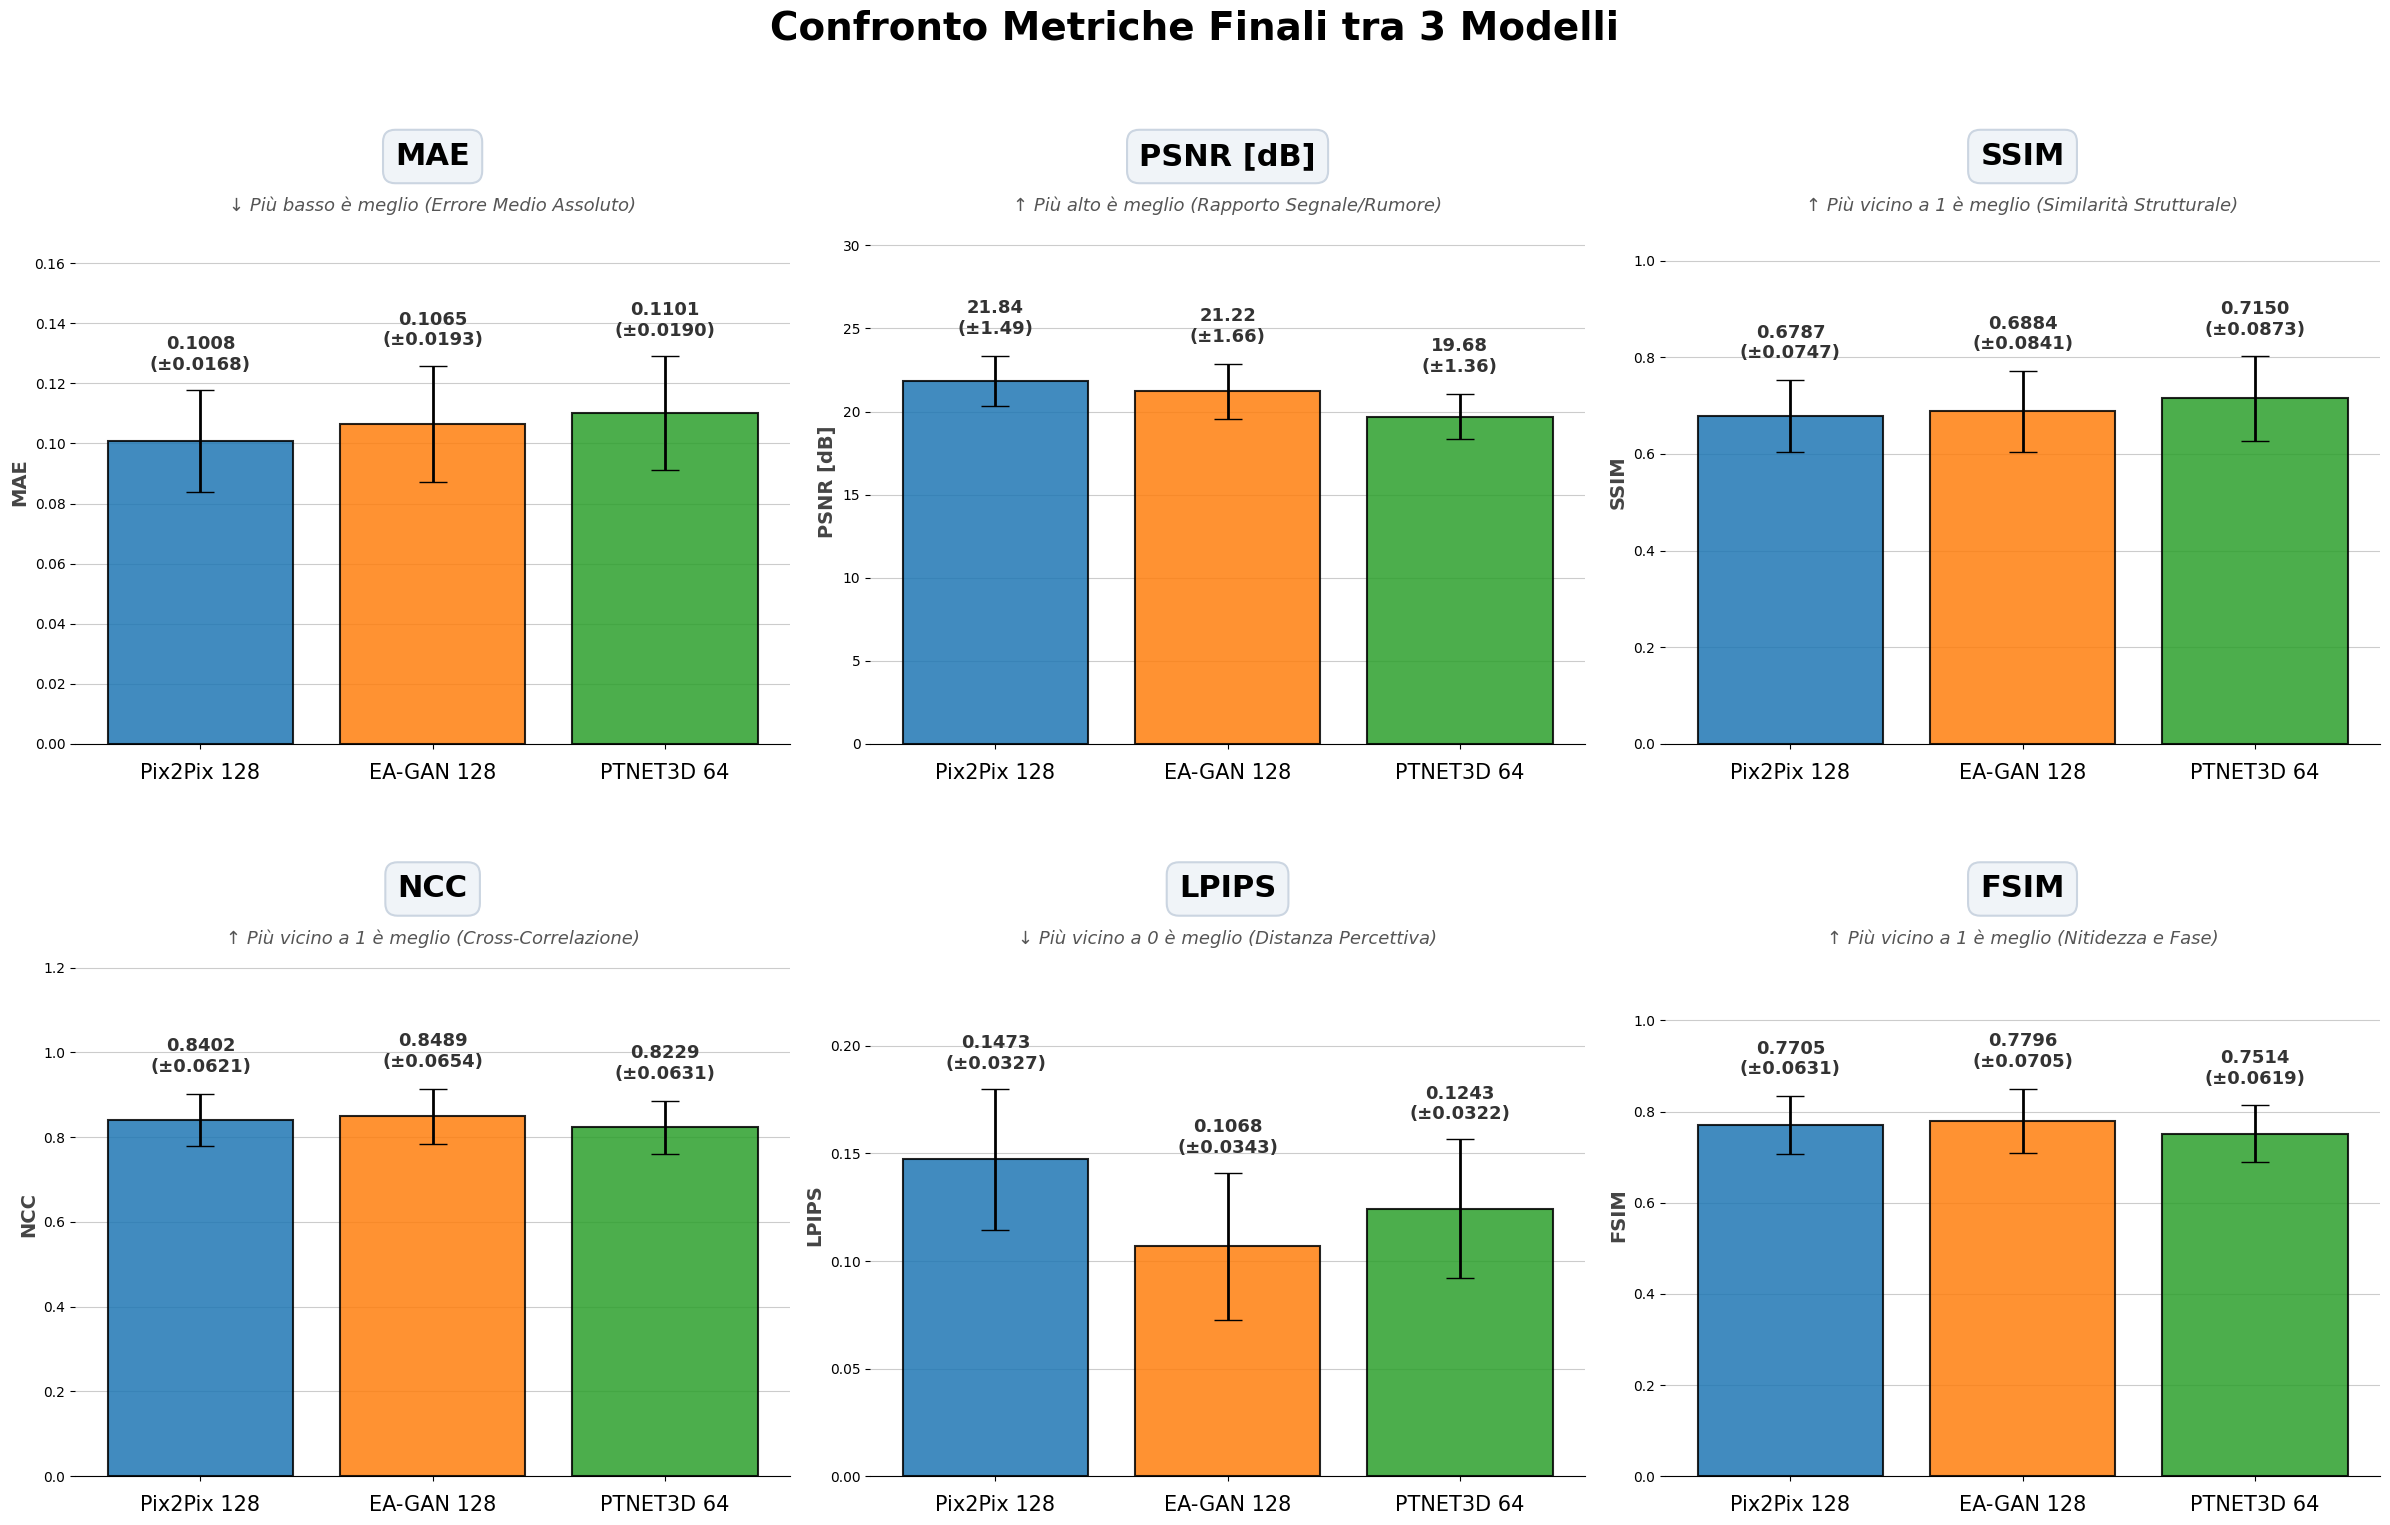

In [12]:
dispositivo = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
nomi_per_plot = ['Pix2Pix 128', 'EA-GAN 128', 'PTNET3D 64']

cartella_input= '/kaggle/input/datasets/collab4444/dataset-2-t1-t2/Prep_IXI_T2/Prep_IXI'
cartella_originali = '/kaggle/input/datasets/collab4444/dataset-2-t1-t2/Prep_IXI_T2/Prep_IXI_T2'
cartella_predizioni = '/kaggle/input/datasets/collab2000/risultati-dataset-2/dataset 2/T1 - T2/T1 to T2'

with torch.inference_mode():
    print("⏳ Calcolo metriche per Pix2Pix...")
    m1 = valuta_modelli_da_due_cartelle(cartella_originali = cartella_originali, cartella_predizioni = cartella_predizioni,  
                                            filtro_modello=['Predizioni_Pix2Pix', 'Predizioni_Pix2Pix (1)'], # <--- NUOVO PARAMETRO
                                             num_slices_percettive=30, 
                                            save_path='/kaggle/working/METRICS/pix2pix',
                                            )
    
    print("⏳ Calcolo metriche per EA-GAN...")
    m2 = valuta_modelli_da_due_cartelle(cartella_originali = cartella_originali, cartella_predizioni = cartella_predizioni,  
                                                filtro_modello=['Predizioni_EAGAN (1)', 'Predizioni_EAGAN'], # <--- NUOVO PARAMETRO
                                                num_slices_percettive=30,
                                                save_path='/kaggle/working/METRICS/eagan',
                                                )
    
    print("⏳ Calcolo metriche per ptnet3D...")
    m3 = valuta_modelli_da_due_cartelle(cartella_originali = cartella_originali, cartella_predizioni = cartella_predizioni,  
                                            filtro_modello=['Predizioni_PTNet3D (1)', 'Predizioni_PTNet3D'], # <--- NUOVO PARAMETRO
                                             num_slices_percettive=30,
                                              save_path='/kaggle/working/METRICS/ptnet')
    
    # Plottiamo le metriche
    lista_risultati = [ m1, m2, m3,]
    print("📊 Generazione grafico comparativo delle metriche...")
    plot_confronto_tre_modelli(m1, m2, m3, nomi_modelli= nomi_per_plot, save_path = '/kaggle/working/confronto_modelli_A2B.png')

-> Inizio generazione e salvataggio immagini per 6 pazienti selezionati...
✅ Immagine salvata per registered_image_100 in: /kaggle/working/confronto_A2B_paz_registered_image_100.png
✅ Immagine salvata per registered_image_269 in: /kaggle/working/confronto_A2B_paz_registered_image_269.png
✅ Immagine salvata per registered_image_454 in: /kaggle/working/confronto_A2B_paz_registered_image_454.png
✅ Immagine salvata per registered_image_662 in: /kaggle/working/confronto_A2B_paz_registered_image_662.png
✅ Immagine salvata per registered_image_33 in: /kaggle/working/confronto_A2B_paz_registered_image_33.png
✅ Immagine salvata per registered_image_83 in: /kaggle/working/confronto_A2B_paz_registered_image_83.png
-> Tutte le immagini sono state salvate con successo!


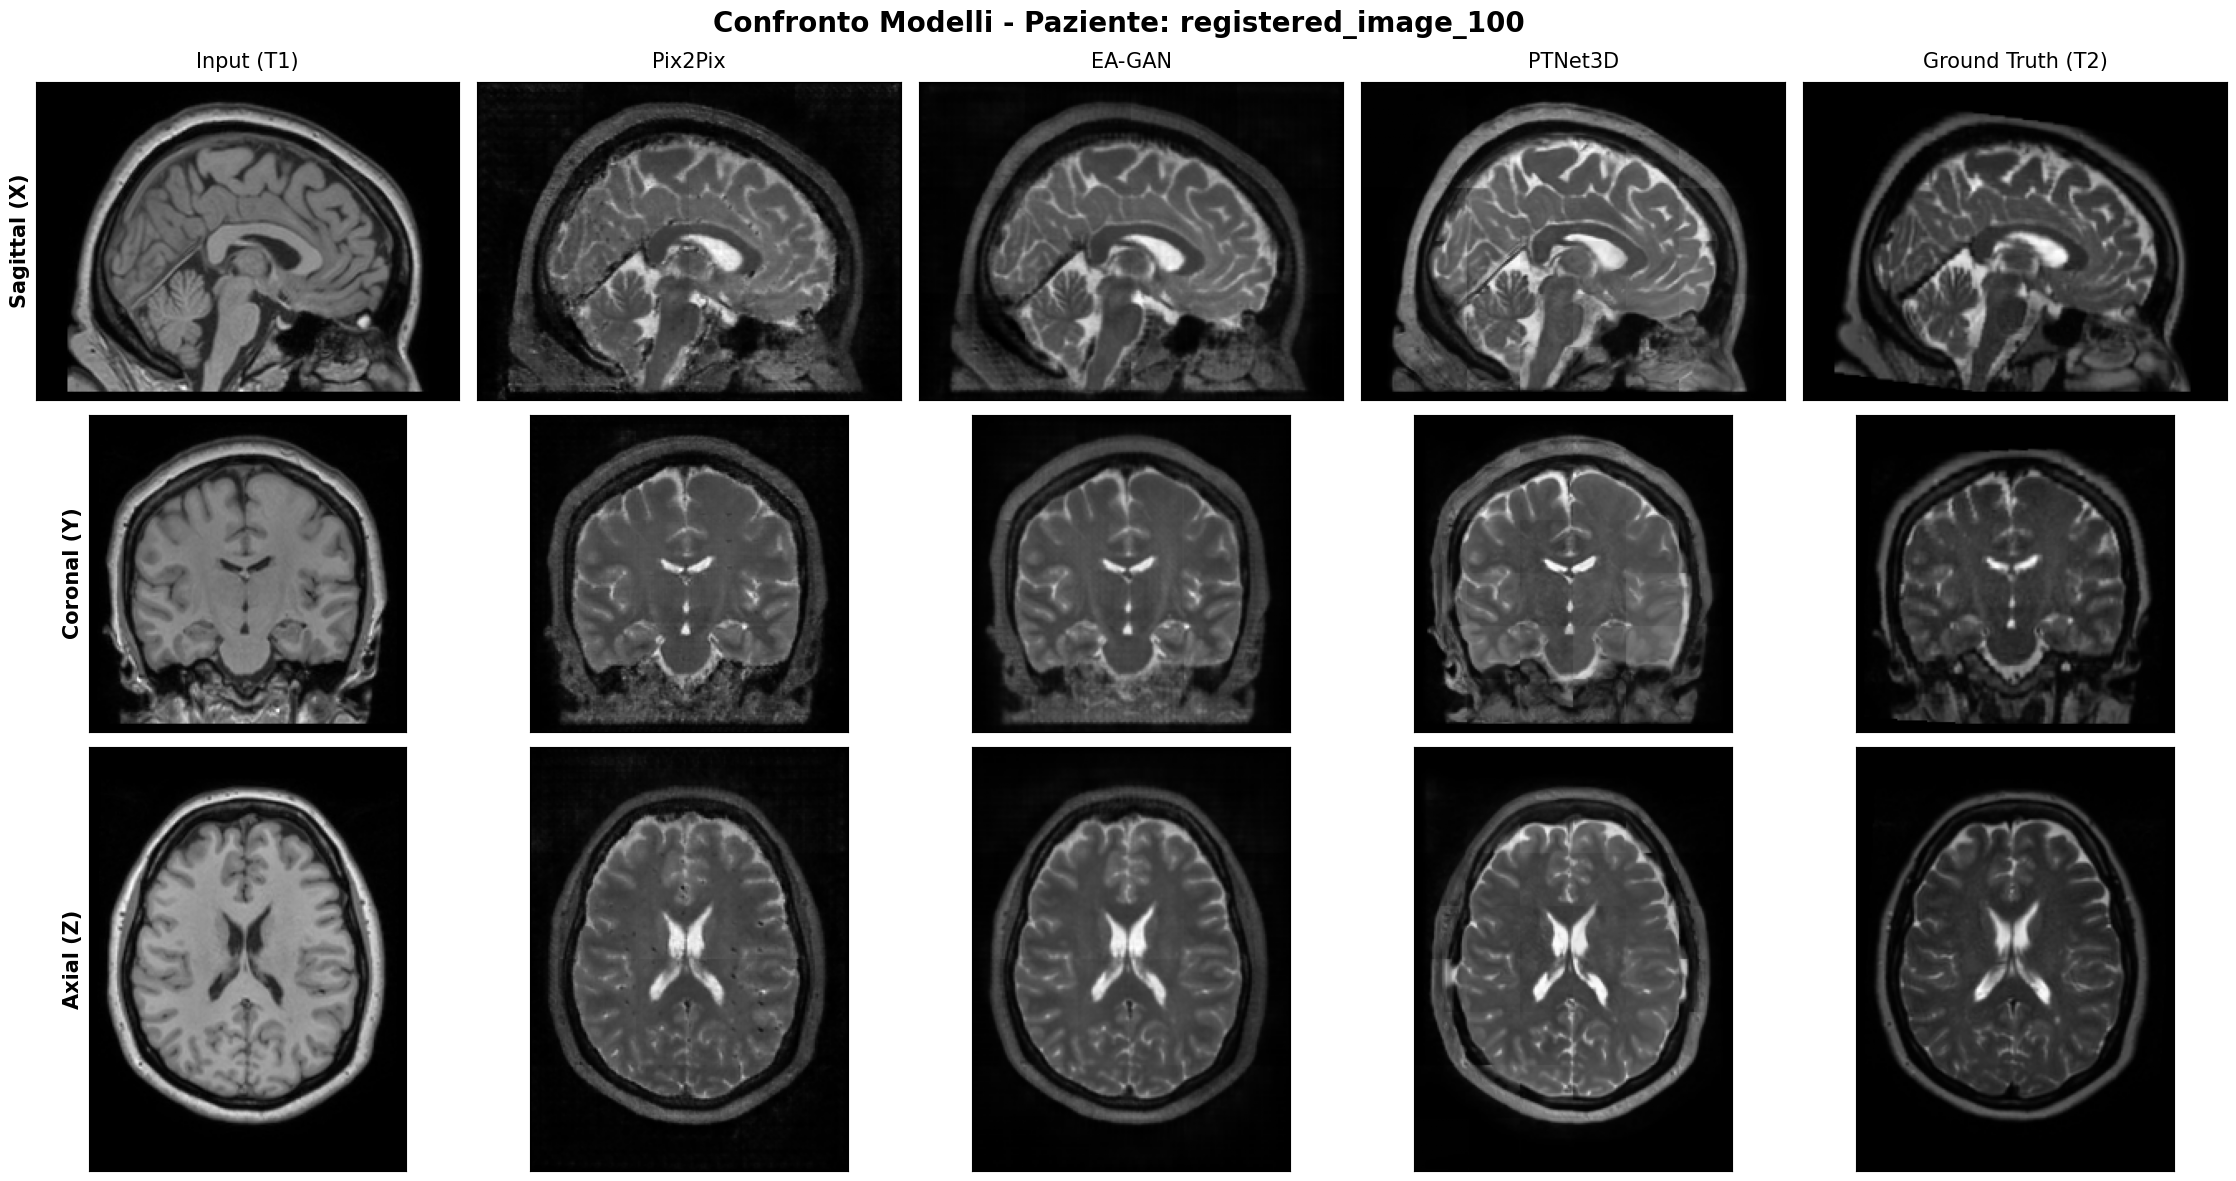

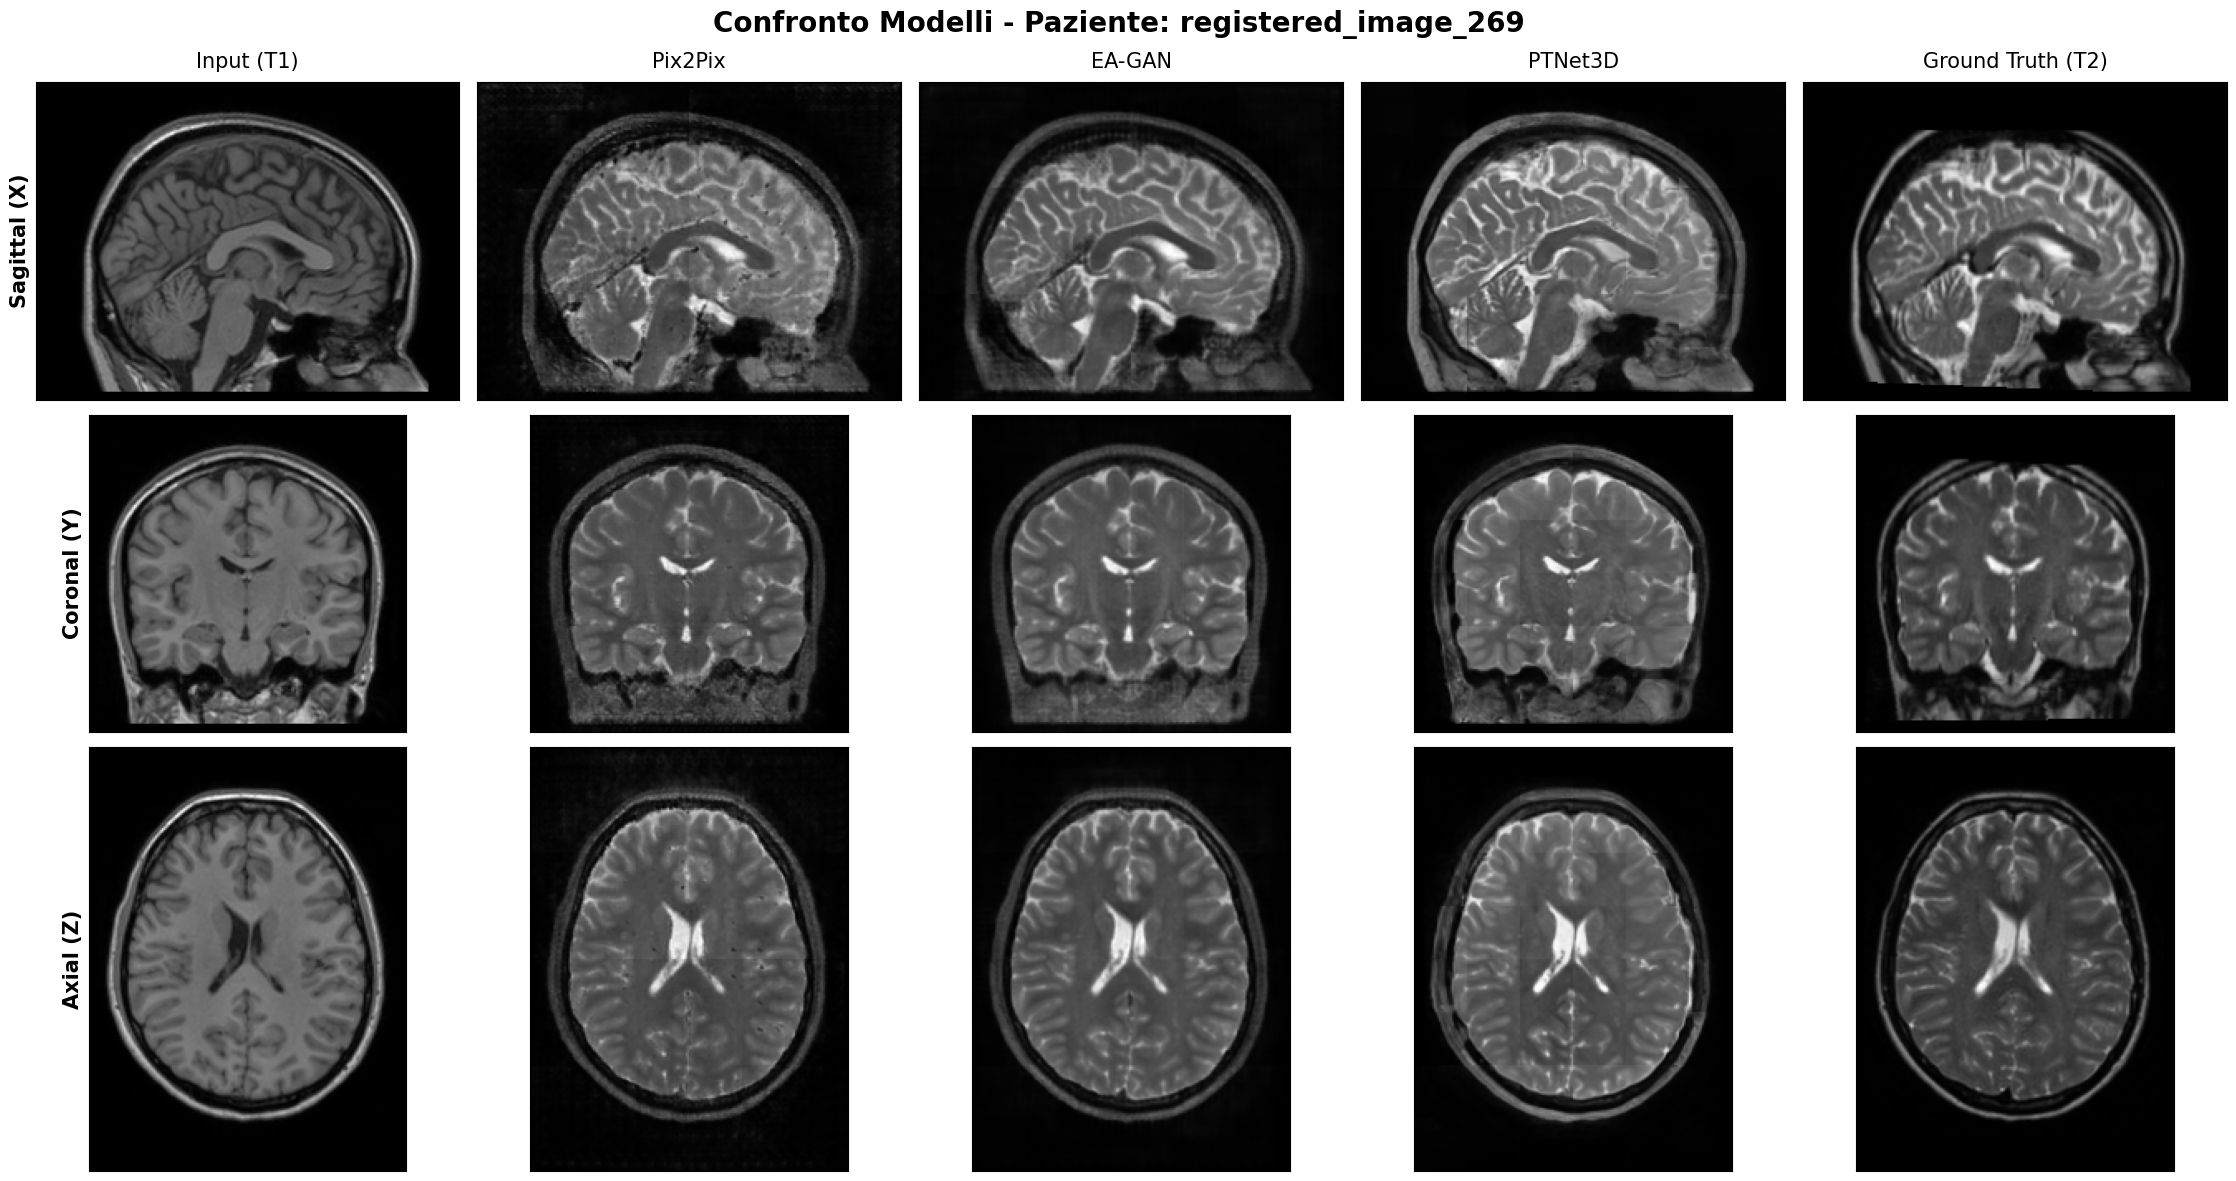

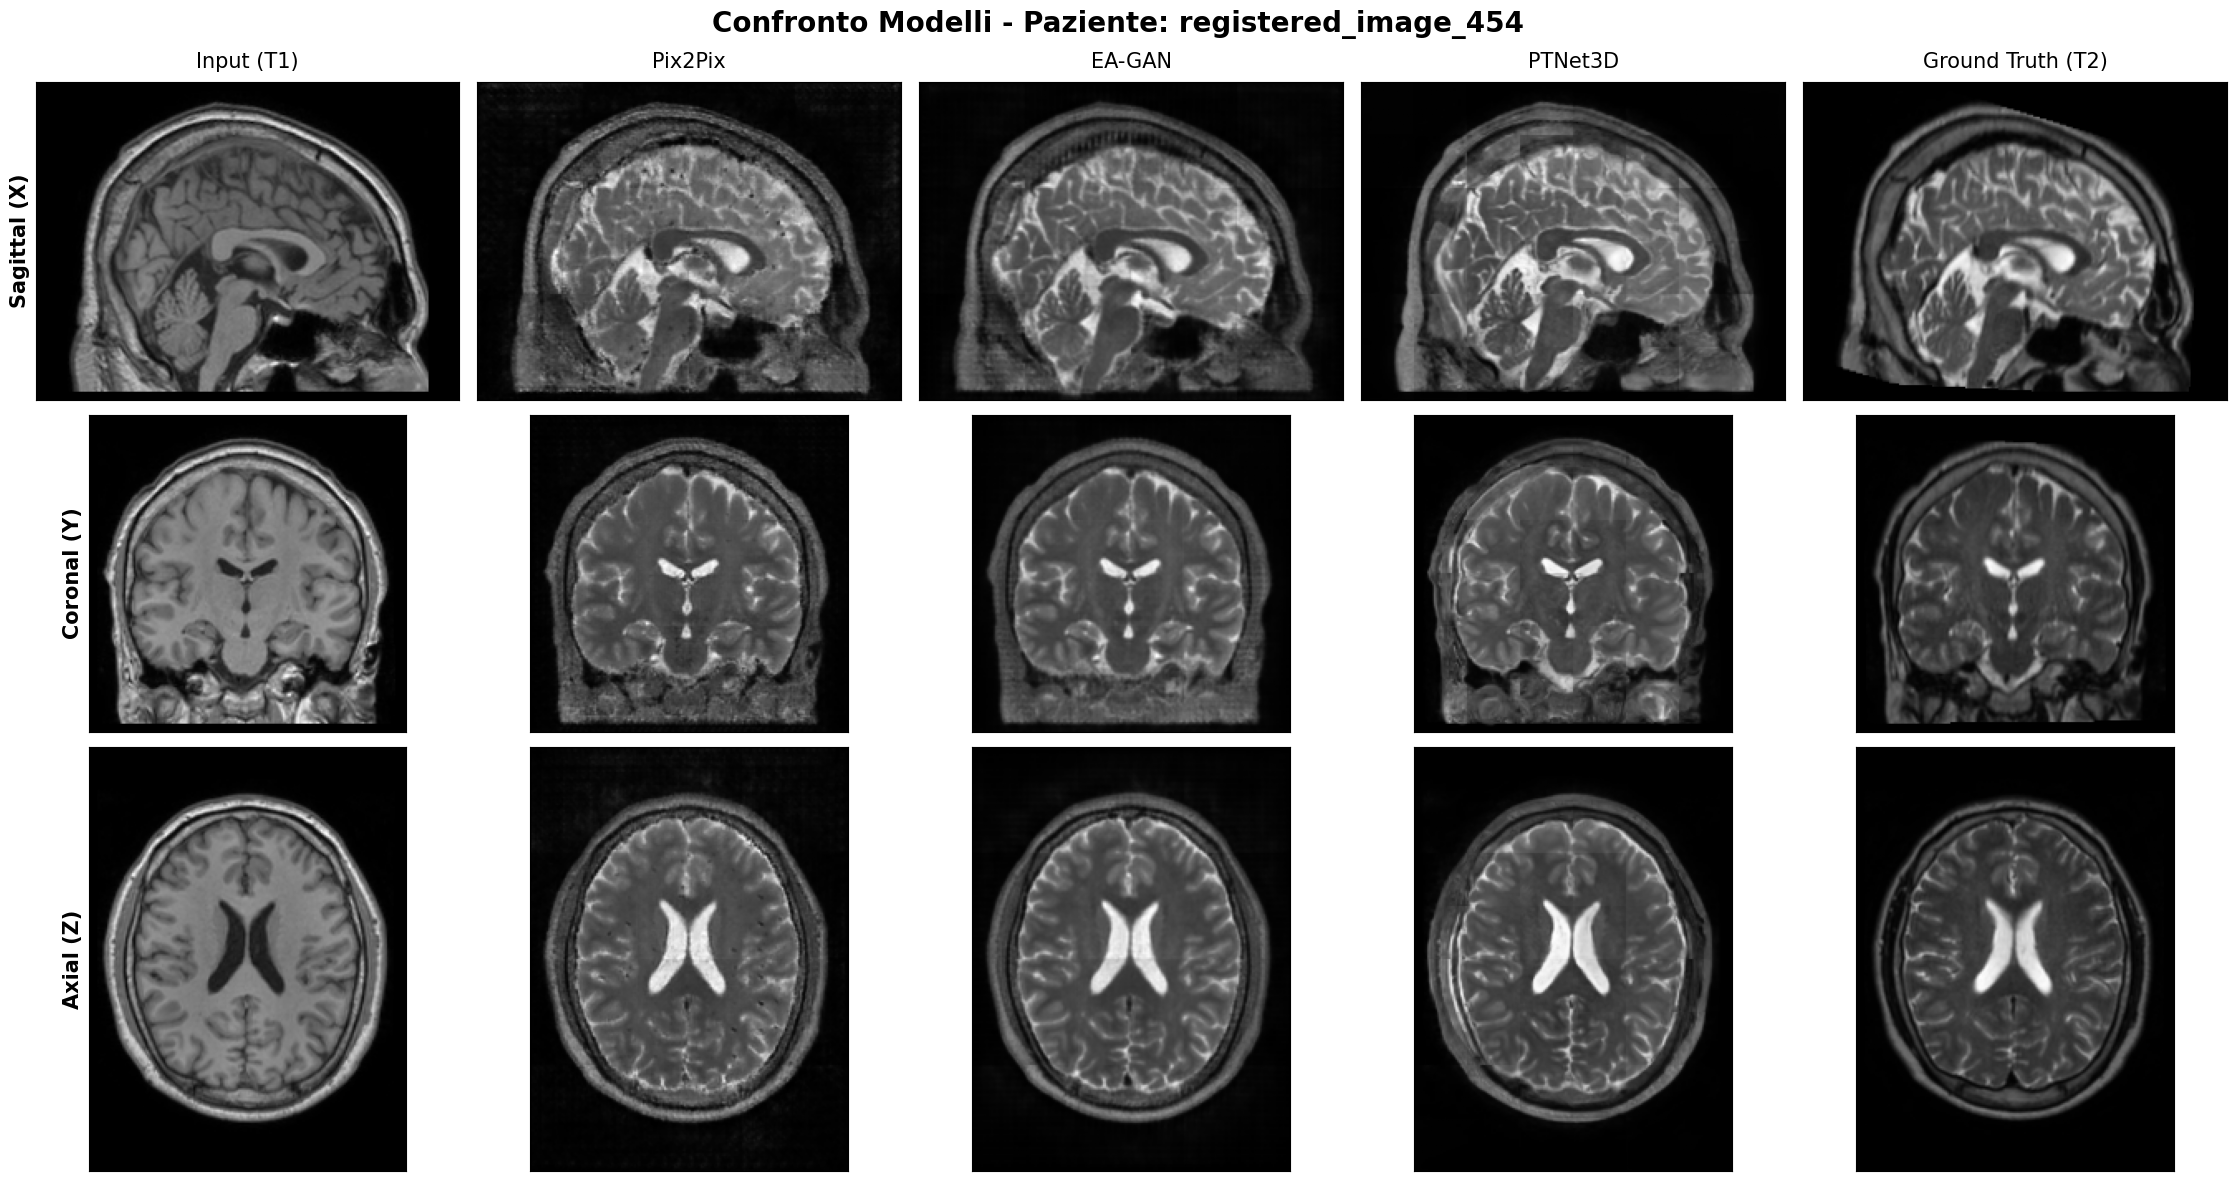

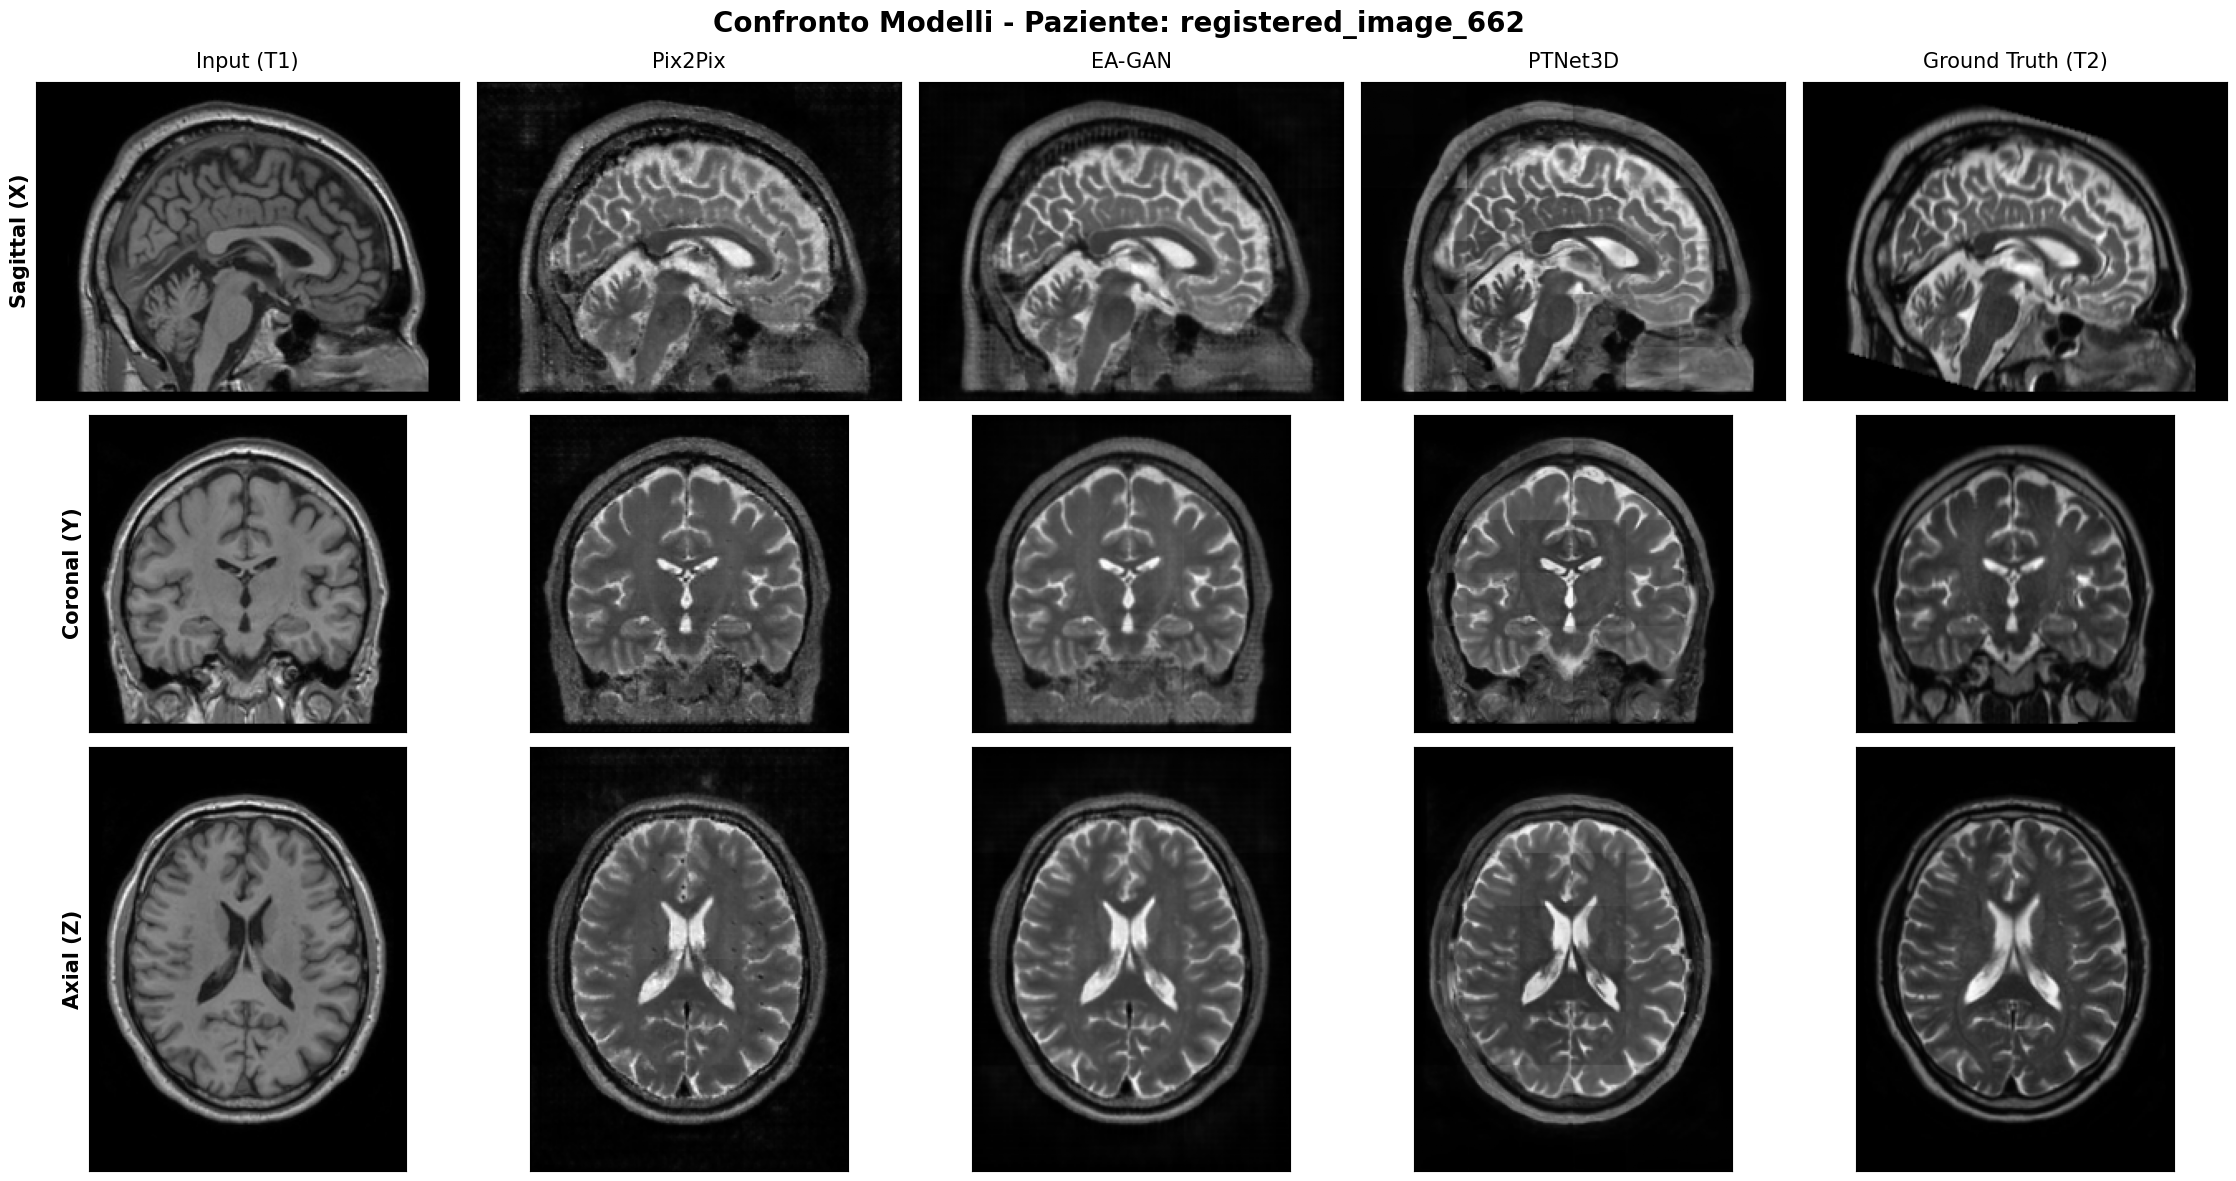

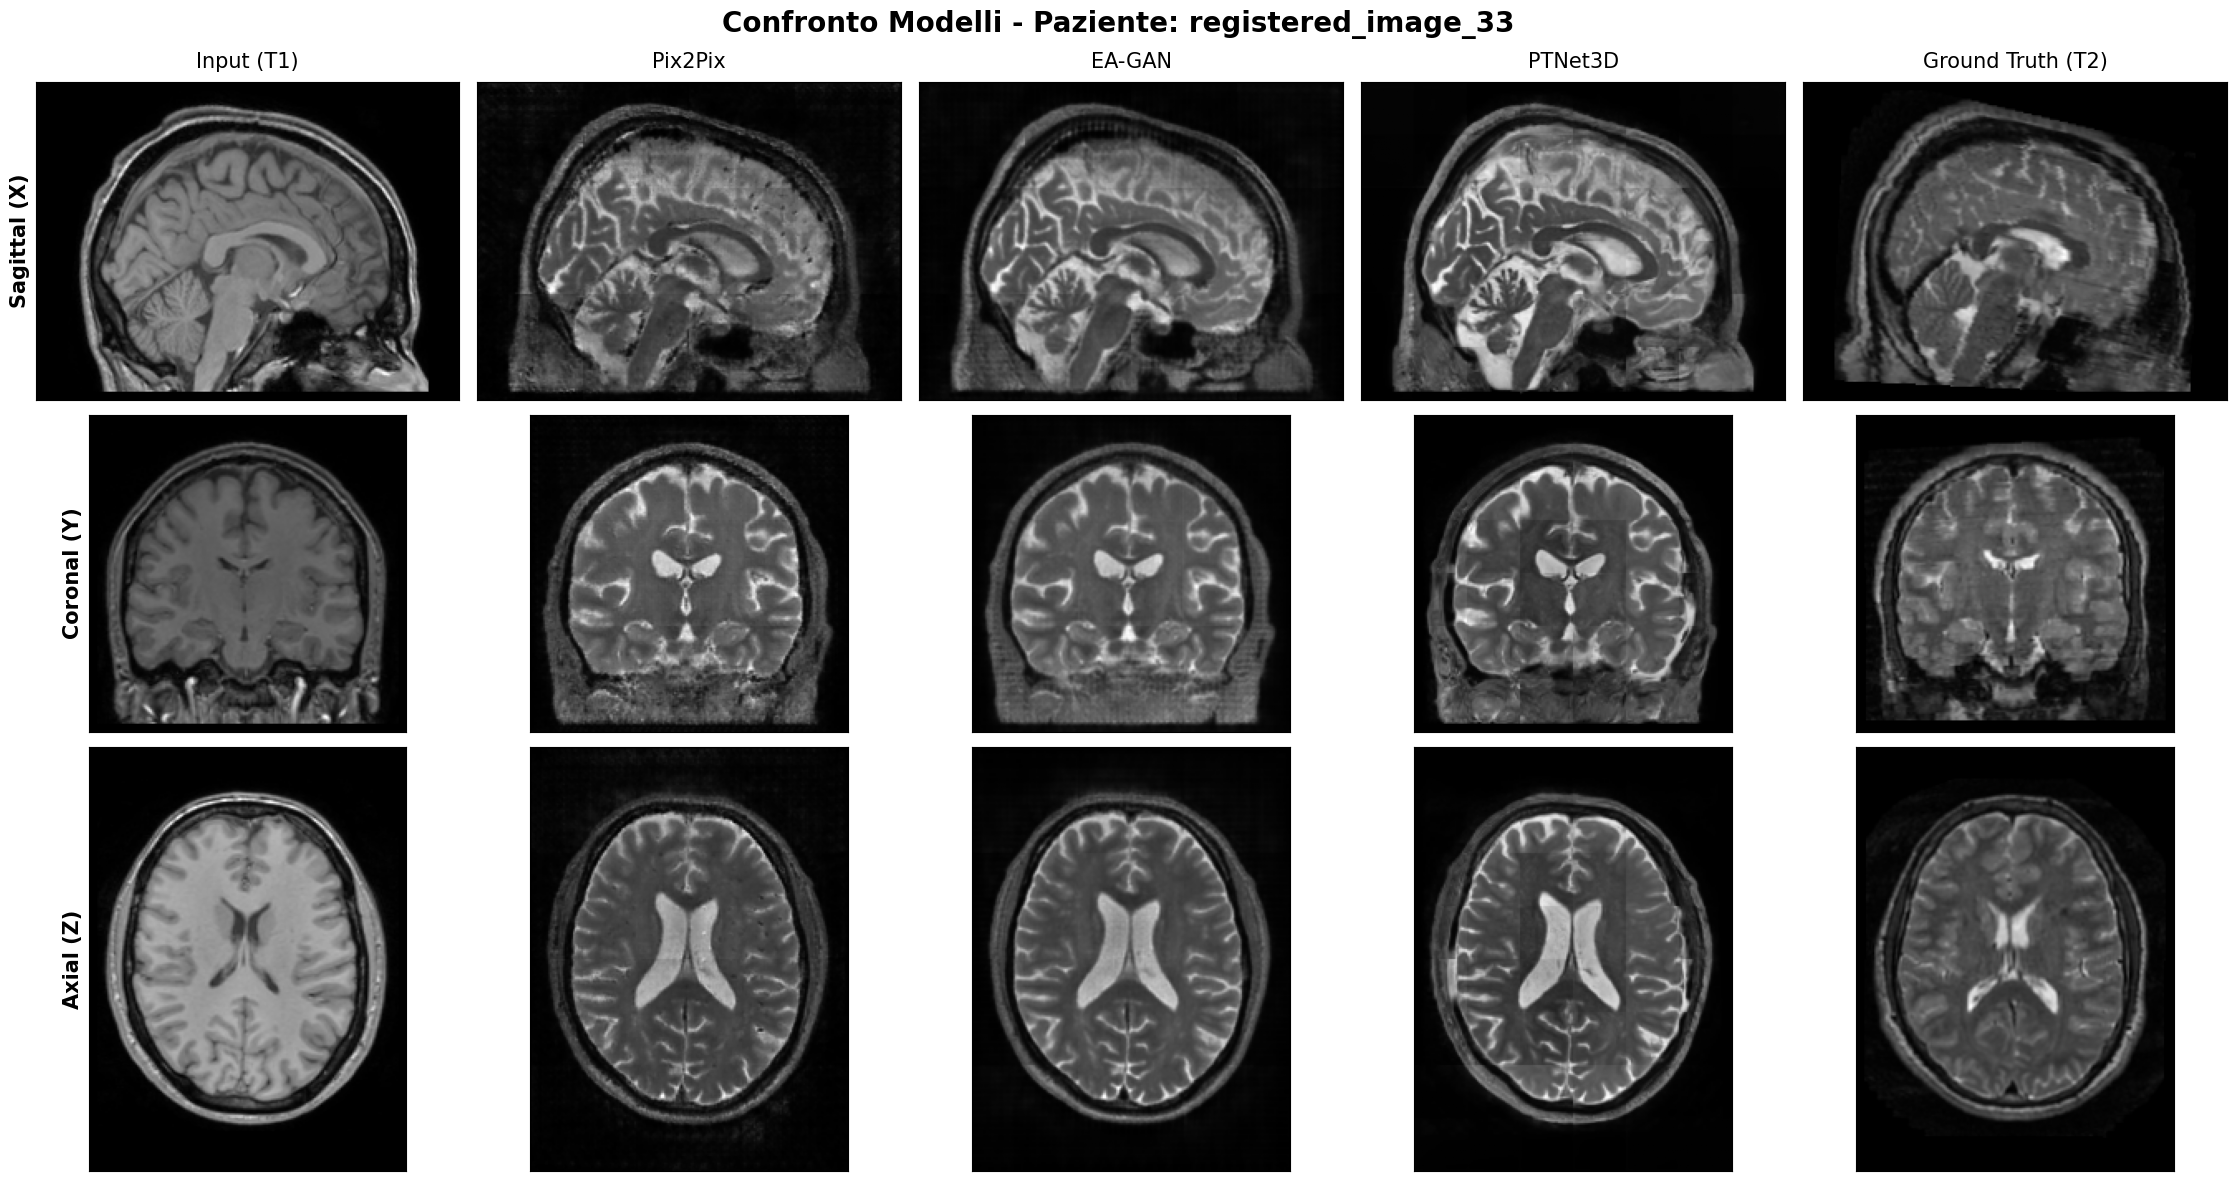

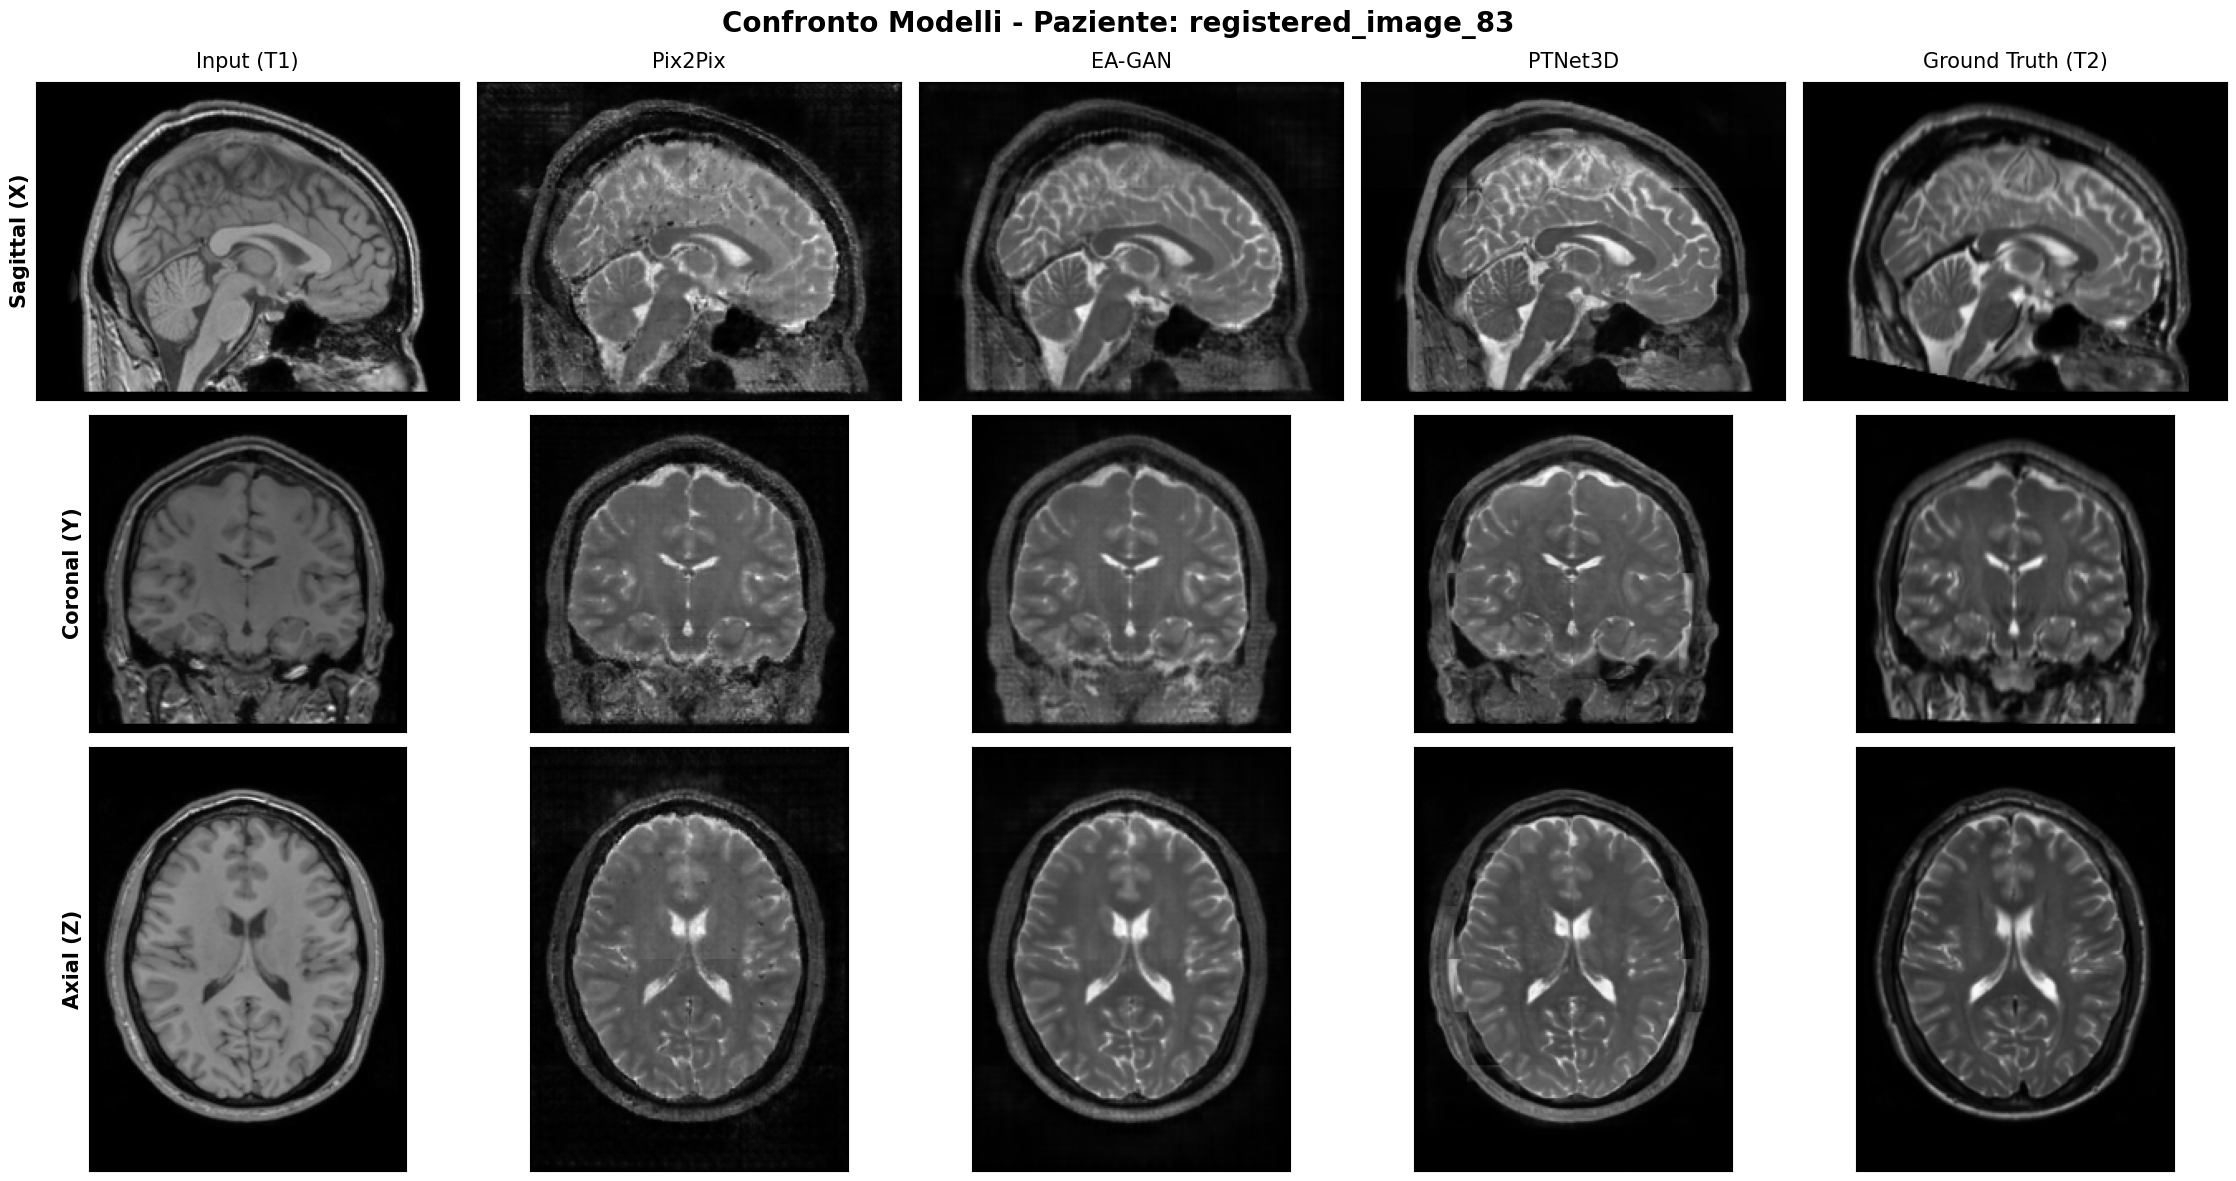

In [13]:
from pathlib import Path

# 3. VISUALIZZAZIONE QUALITATIVA

# Creiamo in anticipo la lista dei file di input per poter estrarre il nome del paziente
files_input = sorted(list(Path(cartella_input).rglob('*.nii')) + list(Path(cartella_input).rglob('*.nii.gz')))

indici_selezionati = [0, 100, 200, 300, 400, 500] 

print(f"-> Inizio generazione e salvataggio immagini per {len(indici_selezionati)} pazienti selezionati...")

for idx in indici_selezionati:
    
    # 1. Estraiamo il nome del paziente "pulito" direttamente dal file NIfTI
    paz_id = files_input[idx].name.replace('.nii.gz', '').replace('.nii', '')
    
    # 2. Definiamo il percorso di salvataggio col vero nome (es: confronto_A2B_paz_registered_image_100.png)
    percorso_salvataggio = f'/kaggle/working/confronto_A2B_paz_{paz_id}.png'
    
    # 3. Chiamata alla funzione
    visualize_confronto_modelli_da_file(
        cartella_target=cartella_originali,
        cartella_predizioni=cartella_predizioni, 
        cartella_input=cartella_input,
        
        # NOTA BENE: Ho messo i due filtri di EAGAN dentro una lista [ ] !
        filtri_modelli=[['Predizioni_Pix2Pix', 'Predizioni_Pix2Pix (1)'], ['Predizioni_EAGAN', 'Predizioni_EAGAN (1)'], ['Predizioni_PTNet3D (1)', 'Predizioni_PTNet3D']],
        
        idx=idx,
        save_path=percorso_salvataggio,
        input_name='T1', 
        output_name='T2',
        nomi_modelli_titoli=['Pix2Pix', 'EA-GAN', 'PTNet3D']
    )

print("-> Tutte le immagini sono state salvate con successo!")